In [32]:
import random
import dill 
import datetime as dt
import glob 
from joblib import Parallel, delayed
import matplotlib.pyplot as plt
import pandas as pd
import scipy.spatial as spatial
import sys 
wd=".."
sys.path.append(wd+'//CPN//')
import numpy as np 
import statsmodels.api as sm
from tqdm import tqdm_notebook, tqdm
import brokenaxes
import math
import os

In [33]:
def make_dir(directory):
    if not os.path.exists(directory):
        os.makedirs(directory)

In [34]:
## A series of functions to parse the  simulation output
def get_run_uuid(sim_output, **kwargs):
    sim_id, sim_data = sim_output
    return(sim_id['uuid'])

def get_run_random_seed(sim_output, **kwargs):
    '''
    '''
    sim_ids, sim_data = sim_output
    random_seed = sim_ids['np.random.seed']
    return(random_seed)

def get_num_echoes_heard(sim_output, **kwargs):
    '''
    '''
    sim_ids, sim_data = sim_output
    num_echoes_heard = np.sum(sim_data[0])
    return(num_echoes_heard)

which_echo = {True: 1 , False:0}

def get_echoids(sim_data, **kwargs):
    '''
    '''
    heard = kwargs.get('heard', True)
    echo_indices = np.argwhere(sim_data[0]==which_echo[heard]).flatten()
    return(echo_indices)    

def get_echo_levels(sim_output, **kwargs):
    '''
    '''
    heard = kwargs.get('heard', True)
    sim_ids, sim_data = sim_output
    echo_ids = get_echoids(sim_data, **kwargs)
    
    echo_levels = sim_data[1]['target_echoes'].loc[echo_ids,'level']
    return(echo_levels)
    

def get_group_size(sim_output, **kwargs):
    ''' This function is necessary because of the
    stupid way I stored the parameter sets using classes
    '''
    sim_ids, sim_data = sim_output
    num_bats_in_group = sim_data[0].size +1 
    return(num_bats_in_group)

def split_by_groupsize(df):
    all_subdfs = []
    group_sizes = np.unique(df['groupsize'])
    for each_groupsize in group_sizes:
        subdf = df[df['groupsize']==each_groupsize]
        all_subdfs.append(subdf)
    return(group_sizes, all_subdfs)



def get_individual_positions(sim_output, **kwargs):
    '''
    '''
    sim_ids, sim_data = sim_output
    _, _b, geometry = sim_data
    positions = geometry['positions']
    return(positions)


def get_detection_distance(sim_output, **kwargs):
    '''
    '''
    heard = kwargs.get('heard', True)
    sim_ids, sim_data = sim_output 
    echo_inds = get_echoids(sim_data, **kwargs)
    individuals_inds = echo_inds +1 # because focal individ is 0 index
    all_positions = get_individual_positions(sim_output)
    heard_individual_positions = all_positions[individuals_inds,:]
    focal_ind = all_positions[0,:]
    distances = spatial.distance
    
    positions_of_relevance = np.row_stack((focal_ind, heard_individual_positions))
    distances = spatial.distance_matrix(positions_of_relevance, 
                                        positions_of_relevance)[1:,0]
    return(distances)

def get_detection_azimuth(sim_output, **kwargs):
    '''
    '''
    heard = kwargs.get('heard', True)
    sim_ids, sim_data = sim_output 
    echo_inds = get_echoids(sim_data, **kwargs)
    
    echoes_heard, sounds, geom = sim_data
    echoes = sounds['target_echoes']
    echo_azimuth = np.array(echoes['theta'][echo_inds])
    
    return(echo_azimuth)


def get_echo_levels(sim_output, **kwargs):
    '''
    '''
    heard = kwargs.get('heard', True)
    sim_ids, sim_data = sim_output 
    echo_inds = get_echoids(sim_data, **kwargs)
    
    echoes_heard, sounds, geom = sim_data
    echoes = sounds['target_echoes']
    echo_level = np.array(echoes['level'][echo_inds])
    
    return(echo_level)
    


def get_nearest_neighbour_distances(sim_output, **kwargs):
    '''Extract the distance to the nearest neighbour of the focal bat
    
    Parameters
    -----------
    sim_output : output from a simulation run. 
    
    Keyword Arguments
    ------------------
    nearest_nbrs : int.
                    The number of distance measurements given. 
                    Defaults to 5. 


    Returns
    ---------
    nearest_neighbour_distances : 1 x nearest_nbrs np.array
    '''
    nearest_nbrs = kwargs.get('nearest_nbrs',5)
    positions = get_individual_positions(sim_output)
    distances = spatial.distance_matrix(positions, positions)[1:,0]
    nearest_neighbour_distances = np.sort(distances)[:nearest_nbrs]
    return(nearest_neighbour_distances)

def get_furthest_bat2bat_distance(sim_output, **kwargs):
    '''
    '''
    positions = get_individual_positions(sim_output)
    distances = spatial.distance_matrix(positions, positions)
    furthest_distance = np.max(distances)
    return(furthest_distance)
    

def extract_parameter_values(one_sim_result, **kwargs):
    '''
    Extracts the variables from the simulation result
    by extracting the values from the 
    'parameter set'
    
    Parameters
    -----------
    one_sim_results : tuple/list with 2 entries. 
                      entry 1 should have the simulation identifiers
                      entry 2 may be anything.
    Keyword Arguments
    -----------------
    variables_to_extract : list with str.
                           The names of the variables that are to be extracted.
                           Notes: 
                           If 'source_level' is one of the variables - only the 
                           emitted levels as dBSPL is output - the reference distance
                           is *ignored*.

    Returns
    --------
    param_set : list.
                A list with the numeric or Boolean values of each of the variables extracted. 
    '''
    sim_identifiers, sim_data = one_sim_result
    all_parameter_values = sim_identifiers['parameter_set']
    
    param_set_for_this_run = []
    for each in kwargs['variables_to_extract']:
        if each != 'source_level':
            param_set_for_this_run.append(all_parameter_values[each])
        elif each == 'source_level':
            param_set_for_this_run.append(all_parameter_values[each]['dBSPL'])
    
    return(param_set_for_this_run)
        
make_to_string = lambda X: str(X)

def join_all_parameters(parameter_list):
    '''
    '''
    params_as_string = map(make_to_string, parameter_list)
    param_joined = '*'.join(params_as_string)
    return(param_joined)

def make_paramset_id(sim_output, **kwargs):
    '''
    '''
    all_parameter_values = extract_parameter_values(sim_output, **kwargs)
    param_id = join_all_parameters(all_parameter_values)
    return(param_id)


def load_simresult(path_to_simresult):
    '''
    '''
    with open(path_to_simresult, 'rb') as sim:
        output = dill.load(sim)
    return(output)

def load_and_extract(simresult_path, extraction_functions, **kwargs):
    '''
    Parameters
    ----------
    simresult_path : str/path object

    extraction_functions : list/tuple with one or more function that work on 
                            the simulation output

    Keyword Arguments
    -----------------
    As defined by the extraction functions. 
    Every key must be unique and correspond to a particular extraction function!

    Returns
    ---------
    extracted_output : object type thats returned by the extraction function
    '''
    simresult = load_simresult(simresult_path)
    extracted_outputs = [ extract(simresult, **kwargs) for extract in extraction_functions]
    return(extracted_outputs)

In [35]:
# Some functions that deal with formatting the simulation data after it's been loaded from the csv file. 

def format_nearest_neighbour_distances(nearest_nbr_entry):
    '''
    Parameters
    ----------
    nearest_nbr_entry : string. 
                        pd.DataFrame column entry with 
                        the following format 
                        '[<float>, <float>, <float>]'
    
    Returns
    -------
    np.array
    
    '''
    only_float_as_string = nearest_nbr_entry[1:-1]
    all_strings_separated = only_float_as_string.split()
    floats = map(lambda X : float(X), all_strings_separated)
    
    distances = np.array(floats)
    return(distances)
    
def split_parameters_joint_to_separate_columns(row, col_names):
    for colnam, value in zip(col_names, row['parameters_joint']):
        row[colnam] = value
    return(row)


In [36]:
results_folder = wd+'/simulations/effect_of_heading_direction/store_results/'
list_of_folder_ids= glob.glob(results_folder+"*")
list_of_folder_ids= [i[len(results_folder):] for i in list_of_folder_ids]
list_of_folder_ids= np.sort(list_of_folder_ids)
# # glob.glob(results_folder+"*")
list_of_folder_ids

array(['0', '10', '30', '50', 'milling', 'swarming'], dtype='<U8')

In [37]:
folder_id= list_of_folder_ids[0]
all_results = glob.glob(results_folder+folder_id+'/*.simresults')
some_results =random.sample(all_results, int(len(all_results)*1.0))
all_results

['../simulations/effect_of_heading_direction/store_results/0/heading_direction_4bbd1a93-c1bc-4881-8e0b-8f7ffd67d750_161445995_.simresults',
 '../simulations/effect_of_heading_direction/store_results/0/heading_direction_31ee5dd6-bf66-4ff7-bfc3-d1874d0a0d71_346422758_.simresults',
 '../simulations/effect_of_heading_direction/store_results/0/heading_direction_8f938079-b1ce-453a-8243-4ed6b7b7d97a_400966404_.simresults',
 '../simulations/effect_of_heading_direction/store_results/0/heading_direction_dfea5d2c-11a9-434e-8c35-81edd944e6fe_980964529_.simresults',
 '../simulations/effect_of_heading_direction/store_results/0/heading_direction_edb3e5e3-2b53-4f93-adf0-f2e67f40db6c_245162161_.simresults',
 '../simulations/effect_of_heading_direction/store_results/0/heading_direction_8ed363ae-babd-4304-b65e-d5b265888df7_405660250_.simresults',
 '../simulations/effect_of_heading_direction/store_results/0/heading_direction_550045f5-664b-4c4f-aa81-2b3c9d160feb_755085763_.simresults',
 '../simulations/eff

In [38]:
extraction_fns = [get_num_echoes_heard, get_group_size, get_furthest_bat2bat_distance,
                 get_nearest_neighbour_distances, get_detection_distance, get_run_uuid,
                  get_run_random_seed,make_paramset_id, extract_parameter_values,
                 get_echo_levels, get_detection_azimuth]
keyword_arguments = {'nearest_nbrs':3}

In [39]:
keyword_arguments['variables_to_extract'] = ['heading_variation', 'echocall_duration','atmospheric_attenuation','min_spacing','source_level',
                        'interpulse_interval', 'implement_shadowing',
                                            ]

In [40]:
what_to_do = input('Do you want to "rerun" from scratch or 2, "reanalyse" from previous data')
task_type= input('What type of analysis is this?')

In [41]:
# if what_to_do == 'rerun':
#     array_containing_all_simulation_datasets = []
#     iterant=0
#     yyyymmdd = dt.datetime.now()
#     timestamp = str([yyyymmdd.year,yyyymmdd.month,yyyymmdd.day,yyyymmdd.hour])
#     make_dir(task_type+'_data'+timestamp+"/")
#     for folder_id in list_of_folder_ids:
#         all_results = glob.glob(results_folder+folder_id+'/*.simresults')
#         some_results =random.sample(all_results, int(len(all_results)*1.0))
        
#         %time extracted_simdata = Parallel(n_jobs=4)(delayed(load_and_extract)(each, extraction_fns, **keyword_arguments) for each in tqdm(some_results))
#         # print(extracted_simdata)
#         echoes_heard = []
#         group_size = []
#         group_diameter = []
#         nearest_3nbrs = []
#         nbr_detection_range = []
#         uuid = []
#         seed = []
#         param_ids = []
#         parameter_values = []
#         echo_levels = []
#         detection_heading_var = []
#         for each in extracted_simdata:
#             for variable, list_to_append in zip(each, [echoes_heard, group_size, group_diameter,
#                                                     nearest_3nbrs, nbr_detection_range,
#                                                     uuid, seed, param_ids, parameter_values,
#                                                     echo_levels, detection_heading_var]):
#                 list_to_append.append(variable)
#         simulation_data = pd.DataFrame(data = {'nbrs_detected':echoes_heard,
#                                         'group_size':group_size,
#                                         'group_diameter':group_diameter,
#                                         'nearest_neighbour_distance':nearest_3nbrs,
#                                         'nbrs_detected_distance':nbr_detection_range,
#                                         'uuid':uuid,
#                                         'seed':seed,
#                                         'paramset_id':param_ids,
#                                         'parameters_joint':parameter_values,
#                                         'echo_levels':echo_levels,
#                                         'detection_azimuth':detection_heading_var})
#         column_names = keyword_arguments['variables_to_extract']

#         for each in column_names:
#             simulation_data[each] = np.nan

#         %time simulation_data = simulation_data.apply(split_parameters_joint_to_separate_columns, 1, col_names=column_names)    
#         yyyymmdd = dt.datetime.now()
#         timestamp = str([yyyymmdd.year,yyyymmdd.month,yyyymmdd.day,yyyymmdd.hour])
#         ##### thanks to https://realpython.com/fast-flexible-pandas/#but-i-heard-that-pandas-is-slow
#         data_store = pd.HDFStore('groupsize_data'+timestamp+'.h5')
#         data_store['simulation_data'] = simulation_data
#         data_store.close()

#         super_array.append(simulation_data)

In [42]:
if what_to_do == 'rerun':
    array_containing_all_simulation_datasets = []
    iterant=0
    yyyymmdd = dt.datetime.now()
    timestamp = str([yyyymmdd.year,yyyymmdd.month,yyyymmdd.day,yyyymmdd.hour])
    make_dir(task_type+'_data'+timestamp+"/")
    for folder_id in list_of_folder_ids:
        all_results = glob.glob(results_folder+str(folder_id)+'/*.simresults')
        some_results =random.sample(all_results, int(len(all_results)*1.0))
        
        %time extracted_simdata = Parallel(n_jobs=4)(delayed(load_and_extract)(each, extraction_fns, **keyword_arguments) for each in tqdm(some_results))
        # print(extracted_simdata)
        echoes_heard = []
        group_size = []
        group_diameter = []
        nearest_3nbrs = []
        nbr_detection_range = []
        uuid = []
        seed = []
        param_ids = []
        parameter_values = []
        echo_levels = []
        detection_angle = []
        for each in extracted_simdata:
            for variable, list_to_append in zip(each, [echoes_heard, group_size, group_diameter,
                                                    nearest_3nbrs, nbr_detection_range,
                                                    uuid, seed, param_ids, parameter_values,
                                                    echo_levels, detection_angle]):
                list_to_append.append(variable)
        simulation_data = pd.DataFrame(data = {'nbrs_detected':echoes_heard,
                                        'group_size':group_size,
                                        'group_diameter':group_diameter,
                                        'nearest_neighbour_distance':nearest_3nbrs,
                                        'nbrs_detected_distance':nbr_detection_range,
                                        'uuid':uuid,
                                        'seed':seed,
                                        'paramset_id':param_ids,
                                        'parameters_joint':parameter_values,
                                        'echo_levels':echo_levels,
                                        'detection_azimuth':detection_angle})
        column_names = keyword_arguments['variables_to_extract']

        for each in column_names:
            simulation_data[each] = np.nan

        %time simulation_data = simulation_data.apply(split_parameters_joint_to_separate_columns, 1, col_names=column_names)    
        

        simulation_data["heading_var"]= len(simulation_data)*[list_of_folder_ids[iterant]]

        ##### thanks to https://realpython.com/fast-flexible-pandas/#but-i-heard-that-pandas-is-slow
        data_store = pd.HDFStore(task_type+'_data'+timestamp+'/'+folder_id+'.h5')
        data_store['simulation_data'] = simulation_data
        data_store.close()

        array_containing_all_simulation_datasets.append(simulation_data)
        iterant+=1

  0%|          | 0/300 [00:00<?, ?it/s]/tmp/ipykernel_894697/1633239107.py:79: DeprecationWarning: `row_stack` alias is deprecated. Use `np.vstack` directly.
/tmp/ipykernel_894697/1633239107.py:79: DeprecationWarning: `row_stack` alias is deprecated. Use `np.vstack` directly.
/tmp/ipykernel_894697/1633239107.py:79: DeprecationWarning: `row_stack` alias is deprecated. Use `np.vstack` directly.
/tmp/ipykernel_894697/1633239107.py:79: DeprecationWarning: `row_stack` alias is deprecated. Use `np.vstack` directly.
  3%|▎         | 8/300 [00:00<00:29,  9.81it/s]/tmp/ipykernel_894697/1633239107.py:79: DeprecationWarning: `row_stack` alias is deprecated. Use `np.vstack` directly.
/tmp/ipykernel_894697/1633239107.py:79: DeprecationWarning: `row_stack` alias is deprecated. Use `np.vstack` directly.
/tmp/ipykernel_894697/1633239107.py:79: DeprecationWarning: `row_stack` alias is deprecated. Use `np.vstack` directly.
/tmp/ipykernel_894697/1633239107.py:79: DeprecationWarning: `row_stack` alias is 

CPU times: user 249 ms, sys: 11.1 ms, total: 260 ms
Wall time: 1.3 s
CPU times: user 17.5 ms, sys: 0 ns, total: 17.5 ms
Wall time: 17.7 ms


  0%|          | 0/300 [00:00<?, ?it/s]/tmp/ipykernel_894697/1633239107.py:79: DeprecationWarning: `row_stack` alias is deprecated. Use `np.vstack` directly.
/tmp/ipykernel_894697/1633239107.py:79: DeprecationWarning: `row_stack` alias is deprecated. Use `np.vstack` directly.
/tmp/ipykernel_894697/1633239107.py:79: DeprecationWarning: `row_stack` alias is deprecated. Use `np.vstack` directly.
/tmp/ipykernel_894697/1633239107.py:79: DeprecationWarning: `row_stack` alias is deprecated. Use `np.vstack` directly.
/tmp/ipykernel_894697/1633239107.py:79: DeprecationWarning: `row_stack` alias is deprecated. Use `np.vstack` directly.
/tmp/ipykernel_894697/1633239107.py:79: DeprecationWarning: `row_stack` alias is deprecated. Use `np.vstack` directly.
/tmp/ipykernel_894697/1633239107.py:79: DeprecationWarning: `row_stack` alias is deprecated. Use `np.vstack` directly.
/tmp/ipykernel_894697/1633239107.py:79: DeprecationWarning: `row_stack` alias is deprecated. Use `np.vstack` directly.
/tmp/ipyk

CPU times: user 257 ms, sys: 5.49 ms, total: 263 ms
Wall time: 469 ms
CPU times: user 58.8 ms, sys: 898 μs, total: 59.7 ms
Wall time: 59.5 ms


  0%|          | 0/300 [00:00<?, ?it/s]/tmp/ipykernel_894697/1633239107.py:79: DeprecationWarning: `row_stack` alias is deprecated. Use `np.vstack` directly.
/tmp/ipykernel_894697/1633239107.py:79: DeprecationWarning: `row_stack` alias is deprecated. Use `np.vstack` directly.
/tmp/ipykernel_894697/1633239107.py:79: DeprecationWarning: `row_stack` alias is deprecated. Use `np.vstack` directly.
/tmp/ipykernel_894697/1633239107.py:79: DeprecationWarning: `row_stack` alias is deprecated. Use `np.vstack` directly.
/tmp/ipykernel_894697/1633239107.py:79: DeprecationWarning: `row_stack` alias is deprecated. Use `np.vstack` directly.
/tmp/ipykernel_894697/1633239107.py:79: DeprecationWarning: `row_stack` alias is deprecated. Use `np.vstack` directly.
/tmp/ipykernel_894697/1633239107.py:79: DeprecationWarning: `row_stack` alias is deprecated. Use `np.vstack` directly.
/tmp/ipykernel_894697/1633239107.py:79: DeprecationWarning: `row_stack` alias is deprecated. Use `np.vstack` directly.
/tmp/ipyk

...

CPU times: user 255 ms, sys: 10.8 ms, total: 266 ms
Wall time: 483 ms
CPU times: user 16.5 ms, sys: 0 ns, total: 16.5 ms
Wall time: 16.5 ms


  0%|          | 0/300 [00:00<?, ?it/s]/tmp/ipykernel_894697/1633239107.py:79: DeprecationWarning: `row_stack` alias is deprecated. Use `np.vstack` directly.
/tmp/ipykernel_894697/1633239107.py:79: DeprecationWarning: `row_stack` alias is deprecated. Use `np.vstack` directly.
/tmp/ipykernel_894697/1633239107.py:79: DeprecationWarning: `row_stack` alias is deprecated. Use `np.vstack` directly.
/tmp/ipykernel_894697/1633239107.py:79: DeprecationWarning: `row_stack` alias is deprecated. Use `np.vstack` directly.
/tmp/ipykernel_894697/1633239107.py:79: DeprecationWarning: `row_stack` alias is deprecated. Use `np.vstack` directly.
/tmp/ipykernel_894697/1633239107.py:79: DeprecationWarning: `row_stack` alias is deprecated. Use `np.vstack` directly.
/tmp/ipykernel_894697/1633239107.py:79: DeprecationWarning: `row_stack` alias is deprecated. Use `np.vstack` directly.
/tmp/ipykernel_894697/1633239107.py:79: DeprecationWarning: `row_stack` alias is deprecated. Use `np.vstack` directly.
/tmp/ipyk

CPU times: user 234 ms, sys: 9.82 ms, total: 244 ms
Wall time: 450 ms
CPU times: user 17.1 ms, sys: 0 ns, total: 17.1 ms
Wall time: 17.1 ms


  0%|          | 0/300 [00:00<?, ?it/s]/tmp/ipykernel_894697/1633239107.py:79: DeprecationWarning: `row_stack` alias is deprecated. Use `np.vstack` directly.
/tmp/ipykernel_894697/1633239107.py:79: DeprecationWarning: `row_stack` alias is deprecated. Use `np.vstack` directly.
/tmp/ipykernel_894697/1633239107.py:79: DeprecationWarning: `row_stack` alias is deprecated. Use `np.vstack` directly.
/tmp/ipykernel_894697/1633239107.py:79: DeprecationWarning: `row_stack` alias is deprecated. Use `np.vstack` directly.
/tmp/ipykernel_894697/1633239107.py:79: DeprecationWarning: `row_stack` alias is deprecated. Use `np.vstack` directly.
/tmp/ipykernel_894697/1633239107.py:79: DeprecationWarning: `row_stack` alias is deprecated. Use `np.vstack` directly.
/tmp/ipykernel_894697/1633239107.py:79: DeprecationWarning: `row_stack` alias is deprecated. Use `np.vstack` directly.
/tmp/ipykernel_894697/1633239107.py:79: DeprecationWarning: `row_stack` alias is deprecated. Use `np.vstack` directly.
/tmp/ipyk

CPU times: user 244 ms, sys: 13.7 ms, total: 258 ms
Wall time: 469 ms
CPU times: user 38.6 ms, sys: 0 ns, total: 38.6 ms
Wall time: 38.6 ms


In [43]:
# if what_to_do == 'reanalyse':
#     # show all datasets in the folder
#     data_stores_in_folder = glob.glob(task_type+'_*]')

#     datastores_by_index = pd.DataFrame(data={'data_stores':data_stores_in_folder})
#     print(datastores_by_index)
#     # user-inputs dataset choice:
#     which_dataset = int(input('Give the index of the dataset you want to'))
#     print()
#     # load a pre-exisiting dataset
#     #load the saved data 
#     list_of_h5_files_in_folder= making_glob_work_properly(datastores_by_index["data_stores"][which_dataset])
#     # print(list_of_h5_files_in_folder); print("./"+datastores_by_index["data_stores"][which_dataset]+'/*')
#     array_containing_all_simulation_datasets_raw = []
#     list_of_folder_ids, list_of_folder_ids_array_version= run_while_reanalysis_to_change_folder_ids(list_of_h5_files_in_folder)
#     for h5_file in list_of_h5_files_in_folder:
#         data_load = pd.HDFStore("./"+datastores_by_index["data_stores"][which_dataset]+'/'+h5_file)
#         simulation_data = data_load['simulation_data']
#         array_containing_all_simulation_datasets_raw.append(simulation_data)
#         data_load.close()

In [44]:
def making_glob_work_properly(subfolder_to_search):
    wd=os.getcwd(); os.chdir(wd+"/"+subfolder_to_search+'/')
    set_of_h5_files= glob.glob("*")
    os.chdir(wd)
    return set_of_h5_files


In [45]:
def passing_true_false_indices_through_lists(list, true_false_list):
    """this is required since list doeesnt support numpy operations and non linear lists can hence not take in true false as indices"""
    output_array= []; iterant=0
    for entry in true_false_list:
        if entry:
            output_array.append(list[iterant])

        iterant+=1
    return output_array

In [46]:
type(simulation_data["group_size"][0])

numpy.int64

In [47]:
unique_heading_vars_in_dataset= np.unique(list_of_folder_ids[:])
list_containing_simulated_data_sorted_by_heading_vars= {}
for heading_var in unique_heading_vars_in_dataset:
    list_containing_simulated_data_sorted_by_heading_vars[heading_var]= []
    sublist_true_false_labels= list_of_folder_ids[:]==heading_var
    sublist_given_heading_var= passing_true_false_indices_through_lists(array_containing_all_simulation_datasets, sublist_true_false_labels)
    list_containing_simulated_data_sorted_by_heading_vars[heading_var].append(sublist_given_heading_var)

unique_heading_vars_in_dataset
list_containing_simulated_data_sorted_by_heading_vars

{np.str_('0'): [[     nbrs_detected  group_size  group_diameter  \
   0                1           5        1.369304   
   1                3          20        2.957724   
   2                3          30        3.873433   
   3                2           5        1.418181   
   4                1          75        6.214403   
   ..             ...         ...             ...   
   295              2          20        2.910441   
   296              4           5        1.368362   
   297              4           5        1.624008   
   298              0          50        4.741600   
   299              9          30        4.033936   
   
                               nearest_neighbour_distance  \
   0    [0.5866024164204637, 0.592792720374432, 0.5942...   
   1    [0.5080772450583707, 0.6135322662847914, 0.660...   
   2    [0.6076886393850807, 0.648153534866189, 0.6670...   
   3    [0.6541888790706933, 0.6751142778367479, 0.698...   
   4    [0.5496909249238446, 0.6183093200

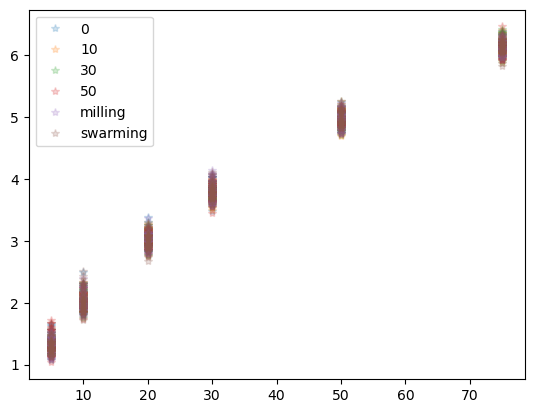

In [48]:
%matplotlib inline
i=0
for var in list_containing_simulated_data_sorted_by_heading_vars.keys():
    subset_given_angle= list_containing_simulated_data_sorted_by_heading_vars[var][0]
    # print(angle)
    for simulation_data in subset_given_angle:
        plt.plot(simulation_data['group_size'],
                    simulation_data['group_diameter'], 
                '*',label=var,alpha=0.2)
        i+=1
    plt.legend()
    # plt.show()

In [49]:
simulation_data.keys()

Index(['nbrs_detected', 'group_size', 'group_diameter',
       'nearest_neighbour_distance', 'nbrs_detected_distance', 'uuid', 'seed',
       'paramset_id', 'parameters_joint', 'echo_levels', 'detection_azimuth',
       'heading_variation', 'echocall_duration', 'atmospheric_attenuation',
       'min_spacing', 'source_level', 'interpulse_interval',
       'implement_shadowing', 'heading_var'],
      dtype='object')

In [50]:
by_minspacing = simulation_data.groupby('min_spacing')
nearest_nbr_dist = {}
for spacing, df in by_minspacing:
    nearest_nbr_distances = df['nearest_neighbour_distance'].reset_index(drop=True)
    nearest_nbr_dist[spacing] = np.concatenate(nearest_nbr_distances)
nearest_nbr_dists_for_plot = [nearest_nbr_dist[0.5]]

In [51]:
data_by_groupsize = simulation_data.groupby(['group_size'])
data_by_groupsize
for groupsize, dataframe in data_by_groupsize:
    print(group_size)

dataframe["nbrs_detected"]

[10, 30, 20, 10, 30, 20, 20, 5, 5, 30, 75, 50, 10, 75, 10, 50, 5, 30, 50, 10, 30, 75, 10, 20, 20, 50, 5, 30, 5, 20, 10, 75, 10, 5, 30, 20, 75, 5, 50, 30, 50, 5, 30, 75, 75, 20, 20, 20, 75, 5, 30, 5, 30, 50, 5, 10, 75, 10, 30, 75, 10, 20, 50, 75, 5, 5, 75, 10, 50, 30, 50, 50, 75, 5, 50, 75, 75, 10, 20, 30, 30, 50, 20, 50, 75, 5, 10, 5, 5, 75, 20, 5, 10, 50, 75, 30, 20, 50, 50, 30, 75, 5, 20, 5, 20, 75, 20, 10, 20, 30, 5, 5, 30, 50, 10, 30, 10, 20, 20, 50, 30, 30, 50, 20, 30, 30, 5, 30, 10, 10, 10, 5, 50, 20, 75, 50, 50, 10, 10, 10, 75, 30, 5, 20, 75, 5, 50, 20, 20, 50, 30, 75, 5, 50, 75, 75, 30, 5, 50, 30, 75, 10, 10, 5, 75, 20, 20, 10, 50, 10, 10, 50, 10, 50, 75, 10, 30, 75, 5, 10, 20, 5, 10, 75, 75, 30, 20, 30, 75, 30, 30, 30, 30, 10, 5, 20, 20, 75, 50, 10, 30, 10, 75, 75, 50, 50, 30, 10, 50, 30, 20, 5, 5, 20, 30, 5, 10, 10, 5, 10, 5, 20, 20, 5, 75, 50, 5, 5, 10, 30, 75, 20, 50, 30, 50, 20, 5, 20, 20, 30, 50, 10, 30, 50, 5, 75, 75, 75, 50, 20, 50, 10, 5, 30, 50, 10, 75, 75, 5, 50, 10,

10     1
13     1
21     2
31     1
36     1
43     1
44     2
48     0
56     2
59     1
63     1
66     2
72     4
75     0
76     0
84     0
89     1
94     2
100    2
105    2
134    2
140    0
144    2
151    0
154    0
155    2
160    2
164    0
174    0
177    1
183    0
184    3
188    0
197    1
202    2
203    0
224    1
230    0
245    1
246    1
247    0
256    0
257    0
262    2
266    1
272    2
277    2
282    0
283    0
293    0
Name: nbrs_detected, dtype: int64

In [52]:
simulation_data["heading_var"]

0      swarming
1      swarming
2      swarming
3      swarming
4      swarming
         ...   
295    swarming
296    swarming
297    swarming
298    swarming
299    swarming
Name: heading_var, Length: 300, dtype: object

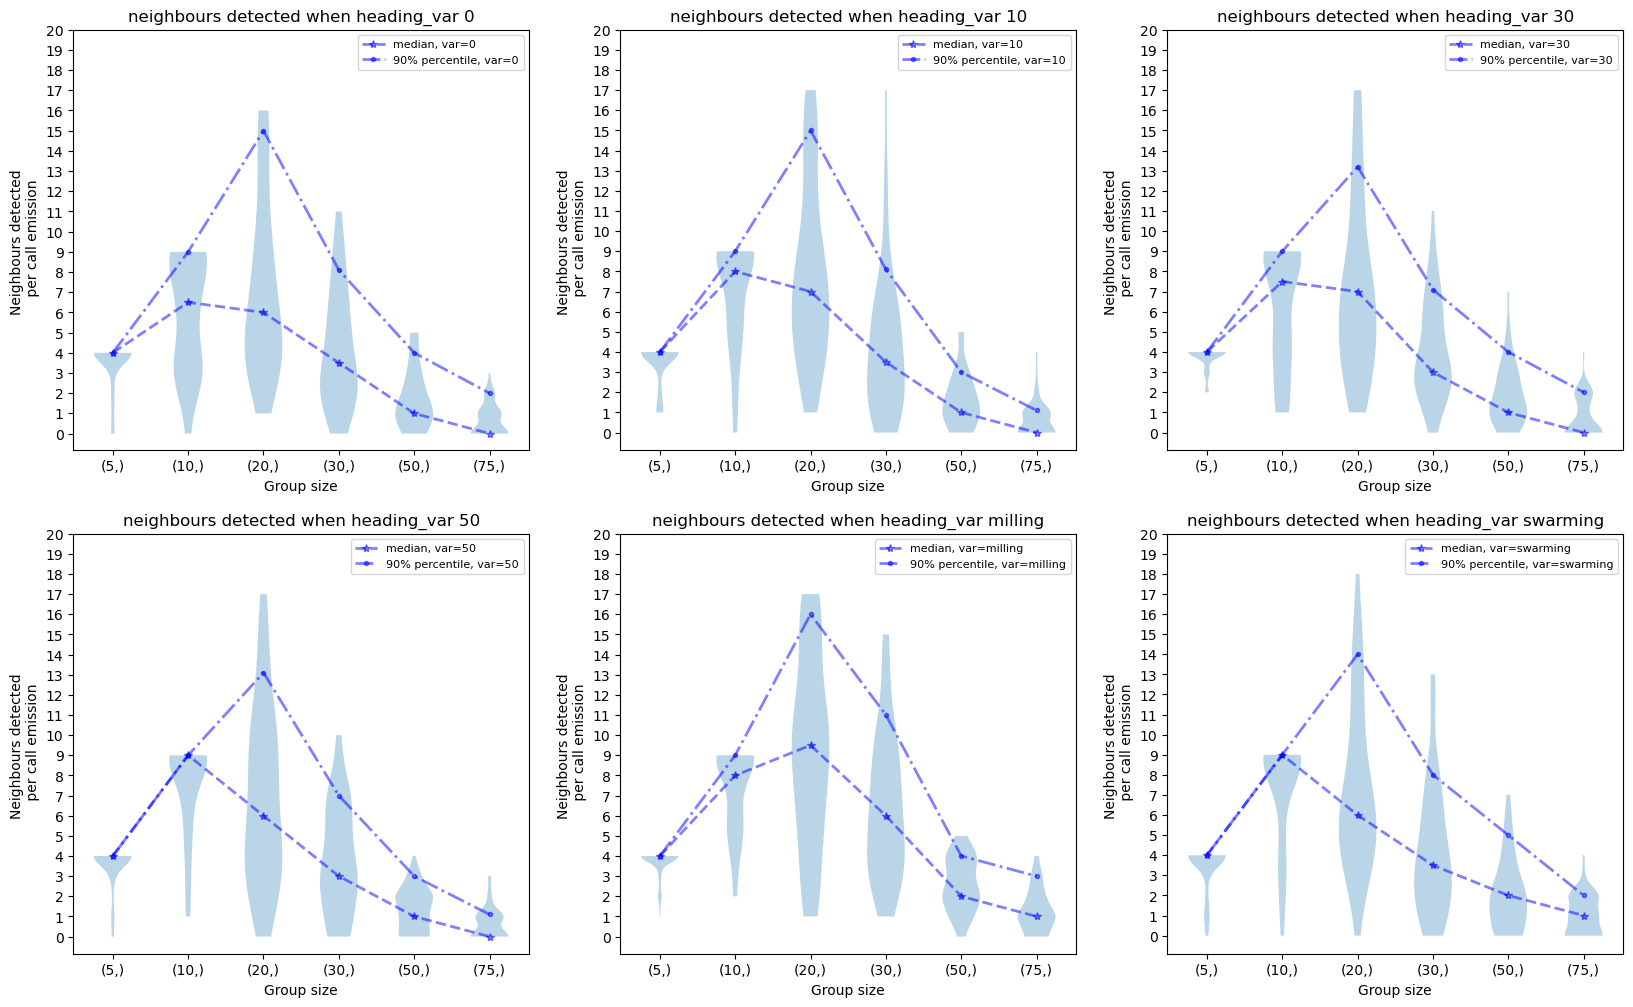

In [53]:
iterant1_axis=0
# fig, axs = plt.subplots(1,3, figsize=(27,9))
# heading_vars= unique_heading_vars_in_dataset
number_of_columns=3; number_of_rows= int(np.floor(len(unique_heading_vars_in_dataset)/number_of_columns))
plt.figure(figsize=(20,12))
i=0
for var in list_containing_simulated_data_sorted_by_heading_vars.keys():
        subset_given_angle= list_containing_simulated_data_sorted_by_heading_vars[var][0]; iterant2_color=0
        colors=["blue", "red", "green", "black"]
        for simulation_data in subset_given_angle:
                data_by_groupsize = simulation_data.groupby(['group_size'])
                nbrs_detected_data = {}
                nbrs_detected_data['num_nbrs'] = []
                nbrs_detected_data['median_num_nbrs'] = []
                nbrs_detected_data['90%ile_num_nbrs'] = []
                groupsizes= []
                for groupsize, dataframe in data_by_groupsize:
                        groupsizes.append(groupsize)
                        nbrs_detected_data['num_nbrs'].append(np.array(dataframe['nbrs_detected']))
                        nbrs_detected_data['median_num_nbrs'].append(np.median(np.array(dataframe['nbrs_detected'])))
                        nbrs_detected_data['90%ile_num_nbrs'].append(np.percentile(np.array(dataframe['nbrs_detected']), 90))

                breakup_x_axis  = np.arange(1,len(groupsizes)+1)+0.5
                nbrs_detected_data['median_num_nbrs']

                # plt.figure(figsize=(7,3.42))
                # plt.subplot(1,2,i)
                plt.subplot(number_of_rows,number_of_columns,i+1)
                plt.violinplot(nbrs_detected_data['num_nbrs'][:], showextrema=False)
                plt.plot(np.arange(1,len(groupsizes)+1),nbrs_detected_data['median_num_nbrs'][:],
                        '--*',linewidth=2, alpha=0.5,label="median, var="+str(simulation_data["heading_var"][0]), color= colors[iterant2_color])#'median')
                # print(np.arange(1,len(groupsizes)))
                plt.plot(np.arange(1,len(groupsizes)+1), nbrs_detected_data['90%ile_num_nbrs'][:],
                        '-..',linewidth=2, alpha=0.5, label="90% percentile, var="+str(simulation_data["heading_var"][0]), color= colors[iterant2_color])#label='90%ile')
                # plt.vlines(breakup_x_axis, -1,20, 'w',linewidth=30,alpha=1.0)
                plt.yticks(np.arange(0,21,1))
                plt.xticks(range(1,len(groupsizes)+1),groupsizes[:])
                plt.legend(fontsize=8)
                plt.ylabel('Neighbours detected \n per call emission', fontsize=10)
                plt.xlabel('Group size', fontsize=10)
                # # plt.ylim(0,20)

                # axs[i].tight_layout()
                plt.title("neighbours detected when heading_var "+str((simulation_data["heading_var"][0])))
                iterant2_color+=1; i+=1
                
        iterant1_axis+=1

In [54]:
list_containing_simulated_data_sorted_by_heading_vars[var][0][0]["heading_var"]

0      swarming
1      swarming
2      swarming
3      swarming
4      swarming
         ...   
295    swarming
296    swarming
297    swarming
298    swarming
299    swarming
Name: heading_var, Length: 300, dtype: object

/tmp/ipykernel_894697/1880929340.py:19: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  dataframe = simulation_data.groupby(['group_size']).get_group(group_size)
/tmp/ipykernel_894697/1880929340.py:19: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  dataframe = simulation_data.groupby(['group_size']).get_group(group_size)
/tmp/ipykernel_894697/1880929340.py:19: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  dataframe = simulation_data.groupby(['group_size']).get_group(group_size)
/tmp/ipykernel_894697/1880929340.py:19: FutureWarning: When g

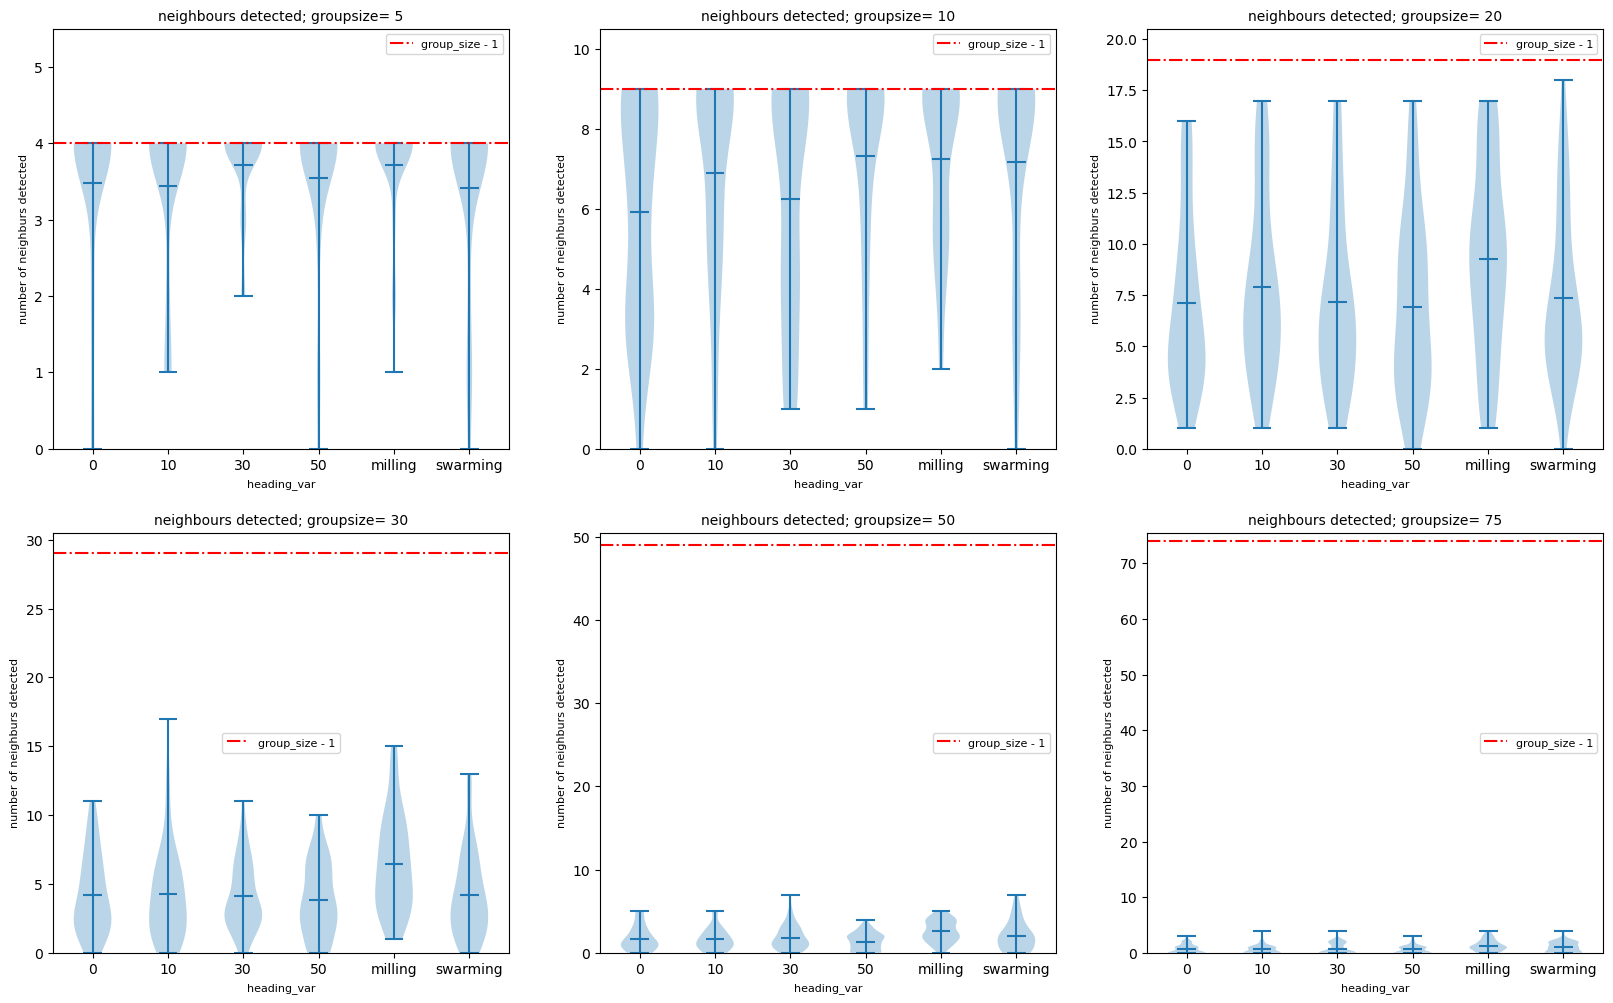

In [55]:
colors=["blue", "red", "green", "black", "pink", "cyan", "yellow"]
# sign_based_on_distance_from_centermost_point= [-1, -1, -1, 0, 1, 1, 1]

group_sizes= [5,10,20,30,50,75]

# fig, axs = plt.subplots(1,1, figsize=(27,9))
i=0; 
number_of_columns=3; number_of_rows= int(np.ceil(len(group_sizes)/number_of_columns))
plt.figure(figsize=(20,12))
for group_size in group_sizes:
    nbrs_detected_data = {}
    nbrs_detected_data['num_nbrs'] = []
    nbrs_detected_data['median_num_nbrs'] = []
    nbrs_detected_data['90%ile_num_nbrs'] = []
    
    x_ticks= []; iterant_sign=0
    for var in list_containing_simulated_data_sorted_by_heading_vars:
        simulation_data= list_containing_simulated_data_sorted_by_heading_vars[var][0][0]
        dataframe = simulation_data.groupby(['group_size']).get_group(group_size)    
        
        nbrs_detected_data['num_nbrs'].append(np.array(dataframe['nbrs_detected']))
        nbrs_detected_data['median_num_nbrs'].append(np.median(np.array(dataframe['nbrs_detected'])))
        nbrs_detected_data['90%ile_num_nbrs'].append(np.percentile(np.array(dataframe['nbrs_detected']), 90))
        x_ticks.append(simulation_data["heading_var"][0])

        iterant_sign+=1

    plt.subplot(number_of_rows,number_of_columns,i+1)
    plt.violinplot(nbrs_detected_data['num_nbrs'], showmeans=True)
    # plt.boxplot(nbrs_detected_data['num_nbrs'], showmeans=True)
    plt.title(f"neighbours detected; groupsize= {group_size}", fontsize= "10")
    plt.xticks(np.arange(1,7),x_ticks)
    # plt.show()
    plt.ylim(0,group_size+0.5)
    plt.axhline(group_size-1, ls="-.", color="red", label= "group_size - 1")
    plt.xlabel("heading_var", fontsize= "8")
    plt.ylabel("number of neighburs detected", fontsize= "8")
    plt.legend(fontsize= "8")

    i+=1

/tmp/ipykernel_894697/1104897239.py:19: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  dataframe = simulation_data.groupby(['group_size']).get_group(group_size)
/tmp/ipykernel_894697/1104897239.py:38: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(fontsize= "8")
/tmp/ipykernel_894697/1104897239.py:19: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  dataframe = simulation_data.groupby(['group_size']).get_group(group_size)
/tmp/ipykernel_894697/1104897239.py:38: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start

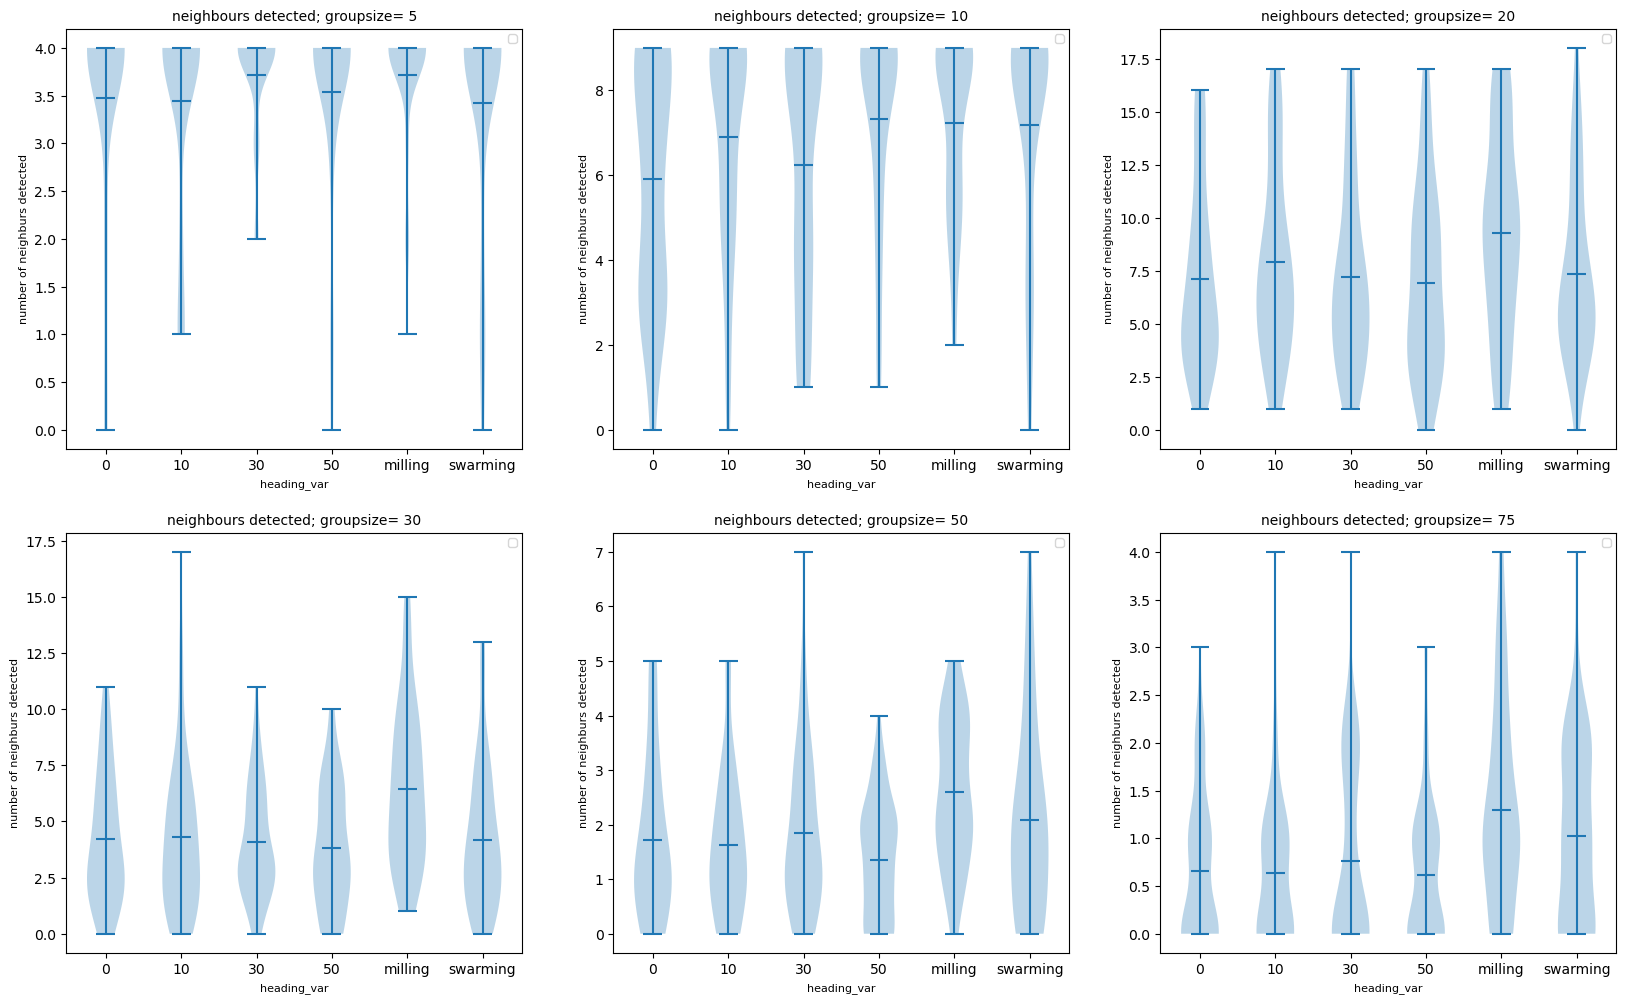

In [56]:
colors=["blue", "red", "green", "black", "pink", "cyan", "yellow"]
# sign_based_on_distance_from_centermost_point= [-1, -1, -1, 0, 1, 1, 1]

group_sizes= [5,10,20,30,50,75]

# fig, axs = plt.subplots(1,1, figsize=(27,9))
i=0; 
number_of_columns=3; number_of_rows= int(np.ceil(len(group_sizes)/number_of_columns))
plt.figure(figsize=(20,12))
for group_size in group_sizes:
    nbrs_detected_data = {}
    nbrs_detected_data['num_nbrs'] = []
    nbrs_detected_data['median_num_nbrs'] = []
    nbrs_detected_data['90%ile_num_nbrs'] = []
    
    x_ticks= []; iterant_sign=0
    for var in list_containing_simulated_data_sorted_by_heading_vars:
        simulation_data= list_containing_simulated_data_sorted_by_heading_vars[var][0][0]
        dataframe = simulation_data.groupby(['group_size']).get_group(group_size)    
        
        nbrs_detected_data['num_nbrs'].append(np.array(dataframe['nbrs_detected']))
        nbrs_detected_data['median_num_nbrs'].append(np.median(np.array(dataframe['nbrs_detected'])))
        nbrs_detected_data['90%ile_num_nbrs'].append(np.percentile(np.array(dataframe['nbrs_detected']), 90))
        x_ticks.append(simulation_data["heading_var"][0])

        iterant_sign+=1

    plt.subplot(number_of_rows,number_of_columns,i+1)
    plt.violinplot(nbrs_detected_data['num_nbrs'], showmeans=True)
    # plt.boxplot(nbrs_detected_data['num_nbrs'], showmeans=True)
    plt.title(f"neighbours detected; groupsize= {group_size}", fontsize= "10")
    plt.xticks(np.arange(1,7),x_ticks)
    # plt.show()
    # plt.ylim(0,group_size+0.5)
    # plt.axhline(group_size-1, ls="-.", color="red", label= "group_size - 1")
    plt.xlabel("heading_var", fontsize= "8")
    plt.ylabel("number of neighburs detected", fontsize= "8")
    plt.legend(fontsize= "8")

    i+=1

In [81]:
array= np.random.randint(0,2,100)
array
calculate_geqNneighbour_distribution(array, 1, 50, 20, False)

[np.float64(0.54),
 np.float64(0.44),
 np.float64(0.4),
 np.float64(0.48),
 np.float64(0.52),
 np.float64(0.5),
 np.float64(0.5),
 np.float64(0.6),
 np.float64(0.38),
 np.float64(0.6),
 np.float64(0.6),
 np.float64(0.46),
 np.float64(0.56),
 np.float64(0.46),
 np.float64(0.56),
 np.float64(0.58),
 np.float64(0.58),
 np.float64(0.5),
 np.float64(0.46),
 np.float64(0.42)]

In [86]:
1- np.array([1,1,1])

array([0, 0, 0])

In [60]:
len(list_containing_simulated_data_sorted_by_heading_vars)

6

In [121]:
#store data
store_probability_of_detection_n_neighbour= {}
group_sizes= [5,10,20,30,50,75]
store_probability_of_detection_n_neighbour
i=0
for var in list_containing_simulated_data_sorted_by_heading_vars:
        simulation_data= list_containing_simulated_data_sorted_by_heading_vars[var][0][0]
        data_by_groupsize = simulation_data.groupby(['group_size'])

        nbrs_detected_data = {}
        nbrs_detected_data["group_sizes"]= group_sizes
        nbrs_detected_data['num_nbrs'] = []
        nbrs_detected_data['median_num_nbrs'] = []
        nbrs_detected_data['90%ile_num_nbrs'] = []
        nbrs_detected_data['detected_distances'] = []
        nbrs_detected_data['neighbours_azimuth'] = []
        nbrs_detected_data['echolevels'] = []
        groupsizes= []

        for groupsize, dataframe in data_by_groupsize:
                if len(dataframe)<30:
                        # print(len(dataframe))
                        continue
                groupsizes.append(groupsize[0])
                nbrs_detected_data['num_nbrs'].append(np.array(dataframe['nbrs_detected']))
                nbrs_detected_data['median_num_nbrs'].append(np.median(np.array(dataframe['nbrs_detected'])))
                nbrs_detected_data['90%ile_num_nbrs'].append(np.percentile(np.array(dataframe['nbrs_detected']), 90))

                nbrs_detected_data['detected_distances'].append(np.concatenate(np.array(dataframe['nbrs_detected_distance'])))

                nbrs_detected_data['neighbours_azimuth'].append(np.concatenate(np.array(dataframe['detection_azimuth'])))

                nbrs_detected_data['echolevels'].append(np.concatenate(np.array(dataframe['echo_levels'])))

        nan_groupsizes= [i for i in group_sizes if i not in groupsizes]

        for nan_groupsize in nan_groupsizes:
                nbrs_detected_data['num_nbrs']= [np.nan, *nbrs_detected_data['num_nbrs']]
                nbrs_detected_data['median_num_nbrs']= [np.nan, *nbrs_detected_data['median_num_nbrs']]
                nbrs_detected_data['90%ile_num_nbrs']= [np.nan, *nbrs_detected_data['90%ile_num_nbrs']]

        nbrs_detected_data['0neighbours'] = [ 1-calculate_geqNneighbour(each,1)  for each in nbrs_detected_data['num_nbrs']]
        nbrs_detected_data['geq_1neighbour'] = [ calculate_geqNneighbour(each,1)  for each in nbrs_detected_data['num_nbrs']]
        nbrs_detected_data['geq_2neighbour'] = [ calculate_geqNneighbour(each,2)  for each in nbrs_detected_data['num_nbrs']]
        nbrs_detected_data['geq_3neighbour'] = [ calculate_geqNneighbour(each,3)  for each in nbrs_detected_data['num_nbrs']]
        nbrs_detected_data['geq_4neighbour'] = [ calculate_geqNneighbour(each,4)  for each in nbrs_detected_data['num_nbrs']]

        nbrs_detected_data['0neighbours_dist'] = [ 1-calculate_geqNneighbour_distribution(each,1, 30, 100, False)  for each in nbrs_detected_data['num_nbrs']]
        nbrs_detected_data['geq_1neighbour_dist'] = [ calculate_geqNneighbour_distribution(each,1, 20, 100, False)  for each in nbrs_detected_data['num_nbrs']]
        nbrs_detected_data['geq_2neighbour_dist'] = [ calculate_geqNneighbour_distribution(each,2, 20, 100, False)  for each in nbrs_detected_data['num_nbrs']]
        nbrs_detected_data['geq_3neighbour_dist'] = [ calculate_geqNneighbour_distribution(each,3, 20, 100, False)  for each in nbrs_detected_data['num_nbrs']]
        nbrs_detected_data['geq_4neighbour_dist'] = [ calculate_geqNneighbour_distribution(each,4, 20, 100, False)  for each in nbrs_detected_data['num_nbrs']]

        # nbrs_detected_data['detected_distances'] = [ np.concatenate(np.array(dataframe['nbrs_detected_distance'])) for groupsize, dataframe in data_by_groupsize]
        nbrs_detected_data['median_detected_distances'] = map(np.median, nbrs_detected_data['detected_distances'])
        nbrs_detected_data['90%ile_detected_distances'] = map(lambda X : np.percentile(X,90),
                                                        nbrs_detected_data['detected_distances'][:-1])

        # nbrs_detected_data['neighbours_azimuth'] = [ np.concatenate(np.array(dataframe['detection_azimuth'])) for groupsize, dataframe in data_by_groupsize]
        nbrs_detected_data['median_neighbours_azimuth'] = [ np.median(each)  for each in nbrs_detected_data['neighbours_azimuth'] ]
        nbrs_detected_data['95%ile_neighbours_azimuth'] = [ np.percentile(each, 97.5)  for each in nbrs_detected_data['neighbours_azimuth'][:-1] ]
        nbrs_detected_data['5%ile_neighbours_azimuth'] = [ np.percentile(each, 2.5)  for each in nbrs_detected_data['neighbours_azimuth'][:-1] ]

        # nbrs_detected_data['echolevels'] = [ np.concatenate(np.array(dataframe['echo_levels'])) for groupsize, dataframe in data_by_groupsize]
        nbrs_detected_data['median_echolevels'] = [ np.median(each) for each in nbrs_detected_data['echolevels']]
        nbrs_detected_data['5%ile_echolevels'] = [ np.percentile(each, 2.5) for each in nbrs_detected_data['echolevels'][:-1]]
        nbrs_detected_data['95%ile_echolevels'] = [ np.percentile(each, 97.5) for each in nbrs_detected_data['echolevels'][:-1]]

        for nan_groupsize in nan_groupsizes:
                nbrs_detected_data['detected_distances']= [np.nan, *nbrs_detected_data['detected_distances']]
                nbrs_detected_data['median_detected_distances']= [np.nan, *nbrs_detected_data['median_detected_distances']]
                nbrs_detected_data['90%ile_detected_distances']= [np.nan, *nbrs_detected_data['90%ile_detected_distances']]

                nbrs_detected_data['neighbours_azimuth']= [[np.nan], *nbrs_detected_data['neighbours_azimuth']]
                nbrs_detected_data['median_neighbours_azimuth']= [np.nan, *nbrs_detected_data['median_neighbours_azimuth']]
                nbrs_detected_data['5%ile_neighbours_azimuth']= [np.nan, *nbrs_detected_data['5%ile_neighbours_azimuth']]
                nbrs_detected_data['95%ile_neighbours_azimuth']= [np.nan, *nbrs_detected_data['95%ile_neighbours_azimuth']]

                nbrs_detected_data['echolevels']= [[np.nan], *nbrs_detected_data['echolevels']]
                nbrs_detected_data['median_echolevels']= [np.nan, *nbrs_detected_data['median_echolevels']]
                nbrs_detected_data['5%ile_echolevels']= [np.nan, *nbrs_detected_data['5%ile_echolevels']]
                nbrs_detected_data['95%ile_echolevels']= [np.nan, *nbrs_detected_data['95%ile_echolevels']]
                
        
        store_probability_of_detection_n_neighbour[simulation_data["heading_var"][0]]= nbrs_detected_data
# for var in list_containing_simulated_data_sorted_by_heading_vars:
#         simulation_data= list_containing_simulated_data_sorted_by_heading_vars[var][0][0]
#         data_by_groupsize = simulation_data.groupby(['group_size'])
#         # print(simulation_data)
#         nbrs_detected_data = {}
#         nbrs_detected_data["group_sizes"]= group_sizes
#         nbrs_detected_data['num_nbrs'] = []
#         nbrs_detected_data['median_num_nbrs'] = []
#         nbrs_detected_data['90%ile_num_nbrs'] = []
#         groupsizes= []

#         for groupsize, dataframe in data_by_groupsize:
#                 groupsizes.append(groupsize)
#                 nbrs_detected_data['num_nbrs'].append(np.array(dataframe['nbrs_detected']))
#                 nbrs_detected_data['median_num_nbrs'].append(np.median(np.array(dataframe['nbrs_detected'])))
#                 nbrs_detected_data['90%ile_num_nbrs'].append(np.percentile(np.array(dataframe['nbrs_detected']), 90))
#         nan_groupsizes= [i for i in group_sizes if i not in groupsizes]
#         for nan_groupsize in nan_groupsizes:
#                 nbrs_detected_data['num_nbrs']= [np.nan, *nbrs_detected_data['num_nbrs']]
#                 nbrs_detected_data['median_num_nbrs']= [np.nan, *nbrs_detected_data['median_num_nbrs']]
#                 nbrs_detected_data['90%ile_num_nbrs']= [np.nan, *nbrs_detected_data['90%ile_num_nbrs']]

#         nbrs_detected_data['0neighbours'] = [ 1-calculate_geqNneighbour(each,1)  for each in nbrs_detected_data['num_nbrs']]
#         nbrs_detected_data['geq_1neighbour'] = [ calculate_geqNneighbour(each,1)  for each in nbrs_detected_data['num_nbrs']]
#         nbrs_detected_data['geq_2neighbour'] = [ calculate_geqNneighbour(each,2)  for each in nbrs_detected_data['num_nbrs']]
#         nbrs_detected_data['geq_3neighbour'] = [ calculate_geqNneighbour(each,3)  for each in nbrs_detected_data['num_nbrs']]
#         nbrs_detected_data['geq_4neighbour'] = [ calculate_geqNneighbour(each,4)  for each in nbrs_detected_data['num_nbrs']]

#         nbrs_detected_data['detected_distances'] = [ np.concatenate(np.array(dataframe['nbrs_detected_distance'])) for groupsize, dataframe in data_by_groupsize]
#         nbrs_detected_data['median_detected_distances'] = map(np.median, nbrs_detected_data['detected_distances'])
#         nbrs_detected_data['90%ile_detected_distances'] = map(lambda X : np.percentile(X,90),
#                                                         nbrs_detected_data['detected_distances'][:-1])

#         nbrs_detected_data['neighbours_azimuth'] = [ np.concatenate(np.array(dataframe['detection_azimuth'])) for groupsize, dataframe in data_by_groupsize]
#         nbrs_detected_data['median_neighbours_azimuth'] = [ np.median(each)  for each in nbrs_detected_data['neighbours_azimuth'] ]
#         nbrs_detected_data['95%ile_neighbours_azimuth'] = [ np.percentile(each, 92.5)  for each in nbrs_detected_data['neighbours_azimuth'][:-1] ]
#         nbrs_detected_data['5%ile_neighbours_azimuth'] = [ np.percentile(each, 2.5)  for each in nbrs_detected_data['neighbours_azimuth'][:-1] ]

#         nbrs_detected_data['echolevels'] = [ np.concatenate(np.array(dataframe['echo_levels'])) for groupsize, dataframe in data_by_groupsize]
#         nbrs_detected_data['median_echolevels'] = [ np.median(each) for each in nbrs_detected_data['echolevels']]
#         nbrs_detected_data['5%ile_echolevels'] = [ np.percentile(each, 2.5) for each in nbrs_detected_data['echolevels'][:-1]]
#         nbrs_detected_data['95%ile_echolevels'] = [ np.percentile(each, 97.5) for each in nbrs_detected_data['echolevels'][:-1]]

#         for nan_groupsize in nan_groupsizes:
#                 nbrs_detected_data['detected_distances']= [np.nan, *nbrs_detected_data['detected_distances']]
#                 nbrs_detected_data['median_detected_distances']= [np.nan, *nbrs_detected_data['median_detected_distances']]
#                 nbrs_detected_data['90%ile_detected_distances']= [np.nan, *nbrs_detected_data['90%ile_detected_distances']]

#                 nbrs_detected_data['neighbours_azimuth']= [[np.nan], *nbrs_detected_data['neighbours_azimuth']]
#                 nbrs_detected_data['median_neighbours_azimuth']= [np.nan, *nbrs_detected_data['median_neighbours_azimuth']]
#                 nbrs_detected_data['5%ile_neighbours_azimuth']= [np.nan, *nbrs_detected_data['5%ile_neighbours_azimuth']]
#                 nbrs_detected_data['95%ile_neighbours_azimuth']= [np.nan, *nbrs_detected_data['95%ile_neighbours_azimuth']]

#                 nbrs_detected_data['echolevels']= [[np.nan], *nbrs_detected_data['echolevels']]
#                 nbrs_detected_data['median_echolevels']= [np.nan, *nbrs_detected_data['median_echolevels']]
#                 nbrs_detected_data['5%ile_echolevels']= [np.nan, *nbrs_detected_data['5%ile_echolevels']]
#                 nbrs_detected_data['95%ile_echolevels']= [np.nan, *nbrs_detected_data['95%ile_echolevels']]
                
        
#         store_probability_of_detection_n_neighbour[simulation_data["heading_var"][0]]= nbrs_detected_data
#         i+=1

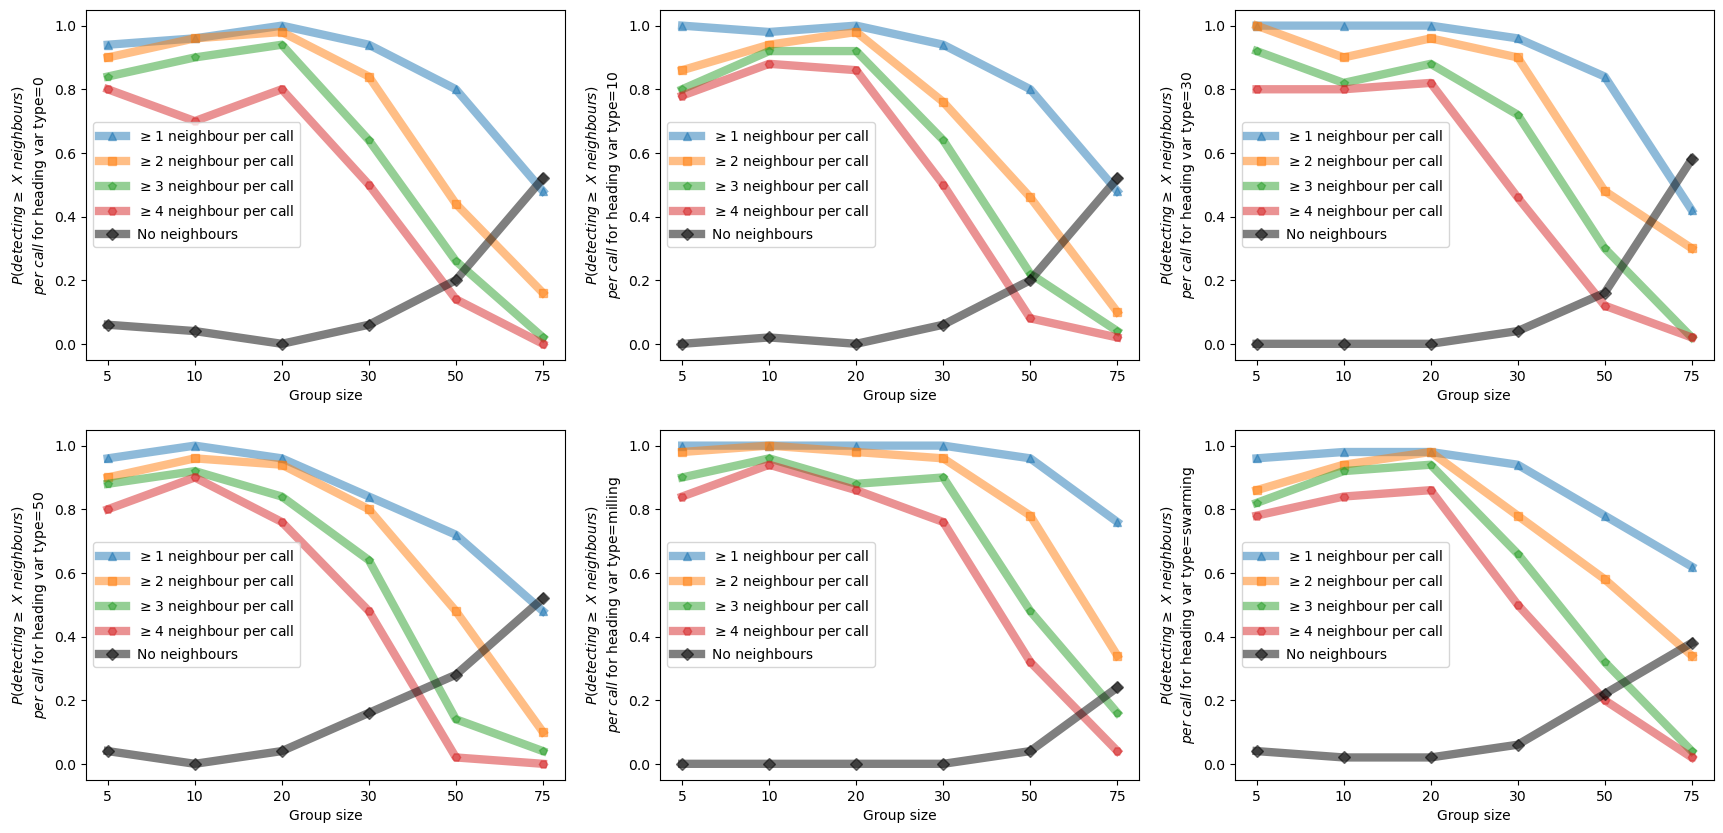

In [62]:
i=0; 
number_of_columns=3; number_of_rows= int(np.ceil(len(list_containing_simulated_data_sorted_by_heading_vars)/number_of_columns))
plt.figure(figsize= (21,10))
for var in list_containing_simulated_data_sorted_by_heading_vars:
        simulation_data= list_containing_simulated_data_sorted_by_heading_vars[var][0][0]
        data_by_groupsize = simulation_data.groupby(['group_size'])
        groupsizes= group_sizes

        key_for_dict= simulation_data["heading_var"][0]
        nbrs_detected_data= store_probability_of_detection_n_neighbour[key_for_dict]

        plt.subplot(number_of_rows,number_of_columns,i+1)
        plt.plot(np.arange(1,len(groupsizes)+1), 
                nbrs_detected_data['geq_1neighbour'], '-^', linewidth=6, alpha=0.5, label='$\geq1$ neighbour per call')
        plt.plot(np.arange(1,len(groupsizes)+1), 
                nbrs_detected_data['geq_2neighbour'], '-s', linewidth=6, alpha=0.5, label='$\geq2$ neighbour per call')
        plt.plot(np.arange(1,len(groupsizes)+1), 
                nbrs_detected_data['geq_3neighbour'], '-p', linewidth=6, alpha=0.5, label='$\geq3$ neighbour per call')
        plt.plot(np.arange(1,len(groupsizes)+1), 
                nbrs_detected_data['geq_4neighbour'], '-H', linewidth=6, alpha=0.5, label='$\geq4$ neighbour per call')
        plt.plot(np.arange(1,len(groupsizes)+1), 
                nbrs_detected_data['0neighbours'], '-Dk', linewidth=6, alpha=0.5, label='No neighbours')

        plt.yticks(fontsize=10)
        plt.xticks(np.arange(1,len(groupsizes)+1),
                groupsizes,fontsize=10)
        plt.legend()
        plt.ylabel('$P(detecting \geq \ X \ neighbours)$'+'\n'+ '$per \ call$ for heading var type='+str(simulation_data["heading_var"][0]),
                fontsize=10)
        plt.xlabel('Group size',
                fontsize=10)
        plt.ylim(-0.05,1.05)
        
        i+=1

In [63]:
np.unique(simulation_data["group_size"])

array([ 5, 10, 20, 30, 50, 75])

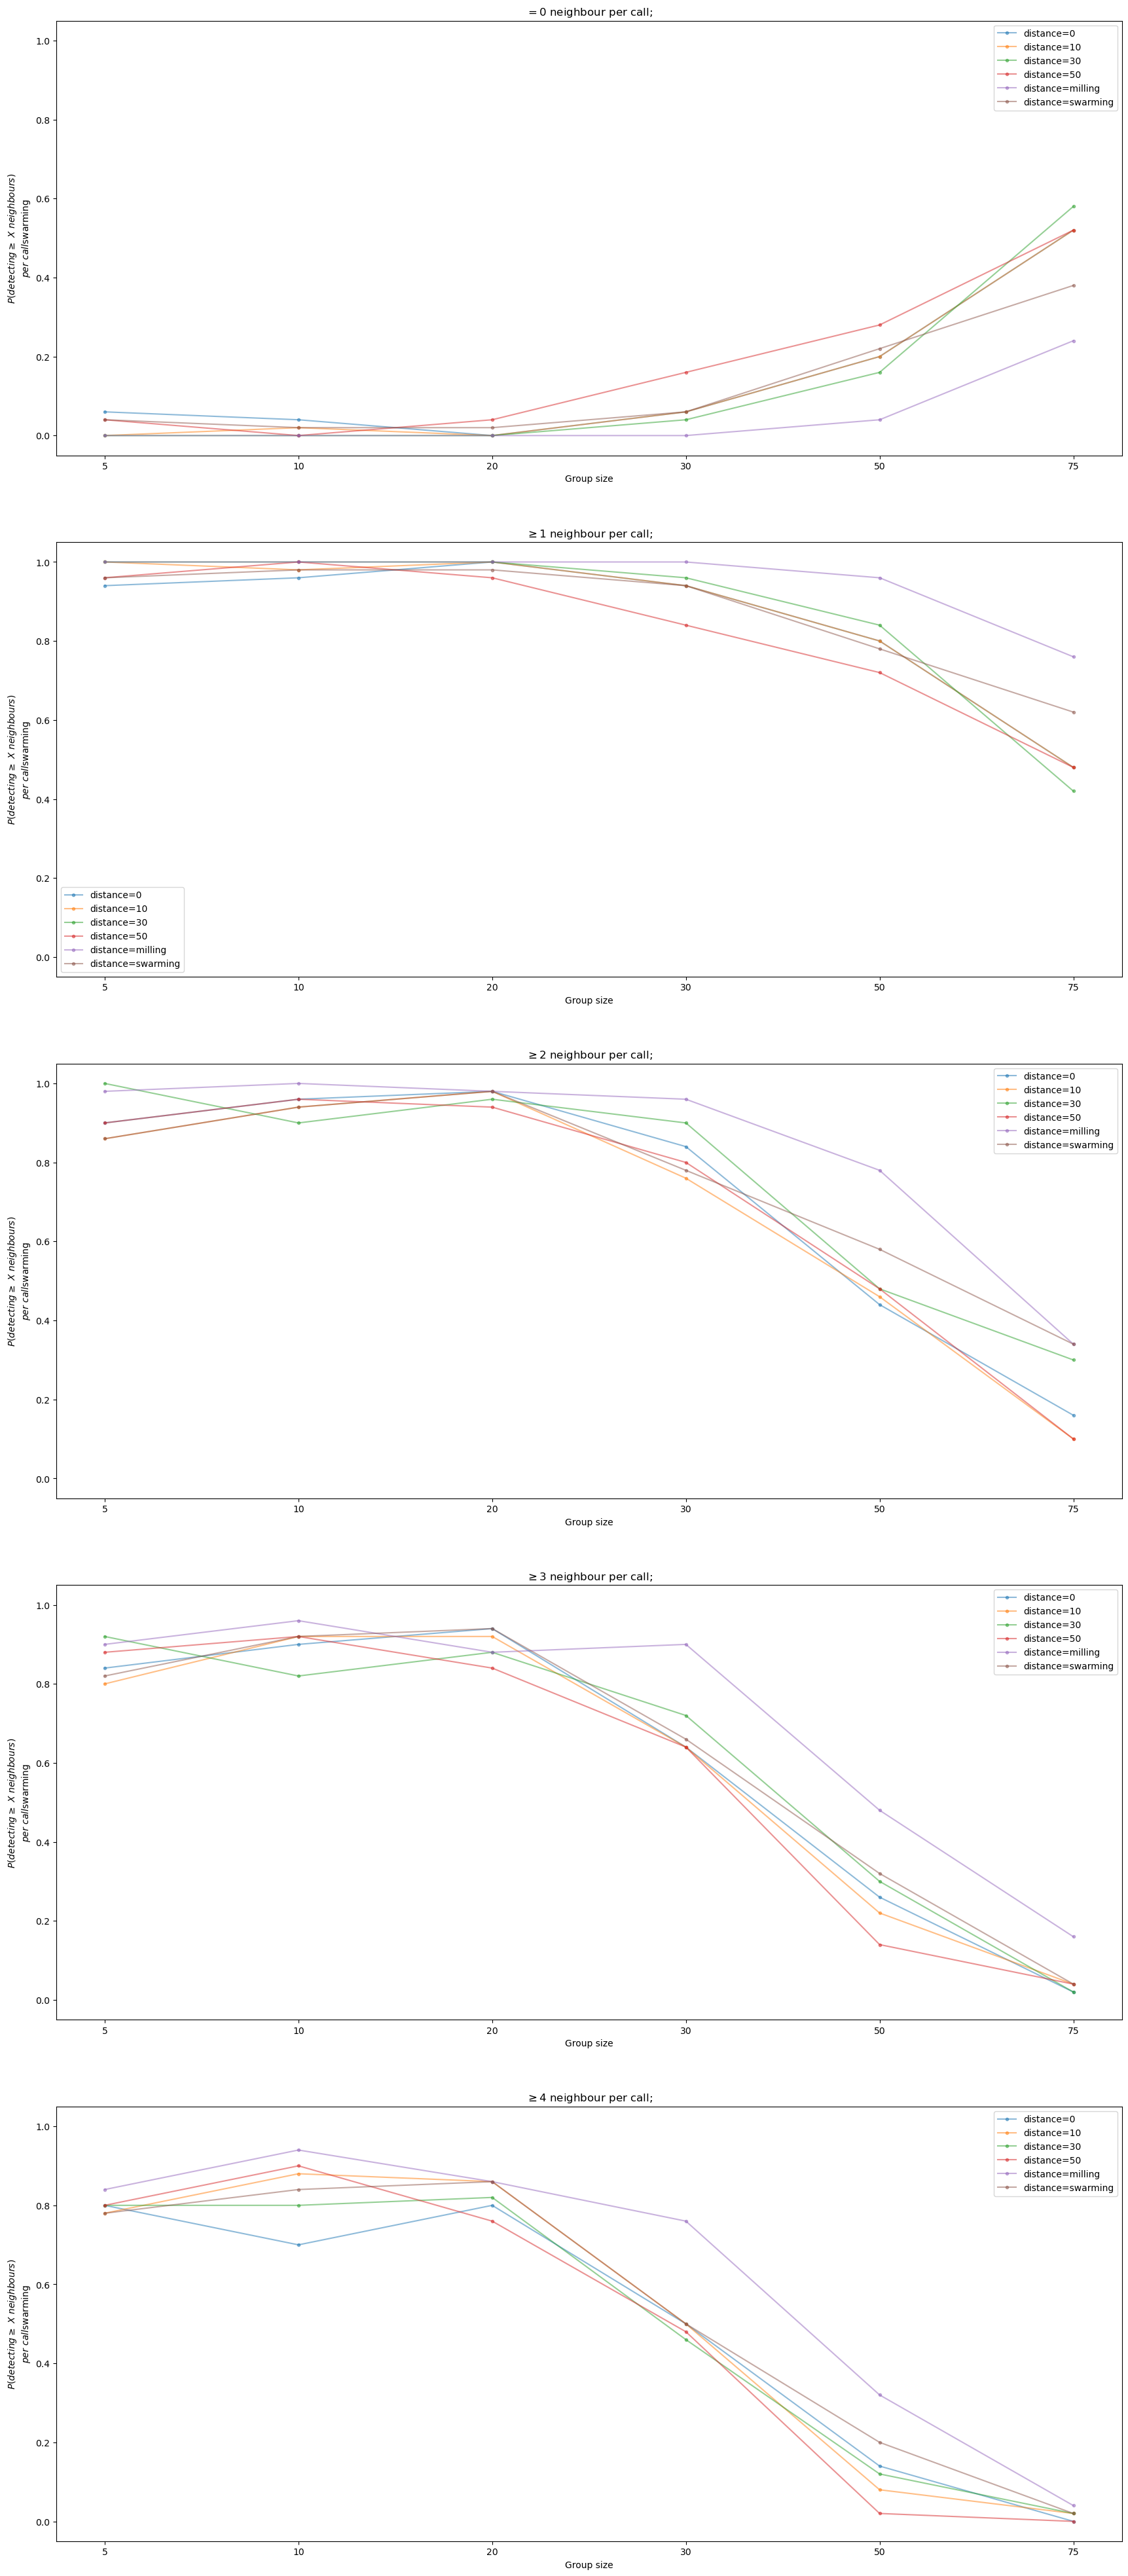

In [64]:
i=0; 
number_of_neighbours_atleast_detected=[0,1,2,3,4]
number_of_columns=1; number_of_rows= int(np.ceil(len(number_of_neighbours_atleast_detected)/number_of_columns))
plt.figure(figsize= (21,50))

for var in list_containing_simulated_data_sorted_by_heading_vars:
        simulation_data= list_containing_simulated_data_sorted_by_heading_vars[var][0][0]
        groupsizes= group_sizes

        key_for_dict= simulation_data["heading_var"][0]
        nbrs_detected_data= store_probability_of_detection_n_neighbour[key_for_dict]

        plt.subplot(number_of_rows,number_of_columns,2)
        plt.plot(np.arange(1,len(groupsizes)+1), 
                nbrs_detected_data['geq_1neighbour'], '.-', alpha=0.5, label=f'distance={key_for_dict}')
        
        plt.subplot(number_of_rows,number_of_columns,3)
        plt.plot(np.arange(1,len(groupsizes)+1), 
                nbrs_detected_data['geq_2neighbour'], '.-', alpha=0.5, label=f'distance={key_for_dict}')
        
        plt.subplot(number_of_rows,number_of_columns,4)
        plt.plot(np.arange(1,len(groupsizes)+1), 
                nbrs_detected_data['geq_3neighbour'], '.-', alpha=0.5, label=f'distance={key_for_dict}')
        
        plt.subplot(number_of_rows,number_of_columns,5)
        plt.plot(np.arange(1,len(groupsizes)+1), 
                nbrs_detected_data['geq_4neighbour'], '.-', alpha=0.5, label=f'distance={key_for_dict}')
        
        plt.subplot(number_of_rows,number_of_columns,1)
        plt.plot(np.arange(1,len(groupsizes)+1), 
                nbrs_detected_data['0neighbours'], '.-', alpha=0.5, label=f'distance={key_for_dict}')
        i+=1
for i in range(1,6):
        if i==1:
                plt.subplot(number_of_rows,number_of_columns,i)
                plt.yticks(fontsize=10)
                plt.xticks(np.arange(1,len(groupsizes)+1),
                        groupsizes,fontsize=10)
                plt.legend()
                plt.title(f"$={i-1}$ neighbour per call;")
        else: 
                plt.subplot(number_of_rows,number_of_columns,i)
                plt.yticks(fontsize=10)
                plt.xticks(np.arange(1,len(groupsizes)+1),
                        groupsizes,fontsize=10)
                plt.legend()
                plt.title(f"$\geq{i-1}$ neighbour per call;")
        plt.ylabel('$P(detecting \geq \ X \ neighbours)$'+'\n'+ '$per \ call$'+str(simulation_data["heading_var"][0]),
                fontsize=10)
        plt.xlabel('Group size',
                fontsize=10)
        plt.ylim(-0.05,1.05)

In [101]:
np.mean([[1,1,1],[1,1,1]], axis=1)

array([1., 1.])

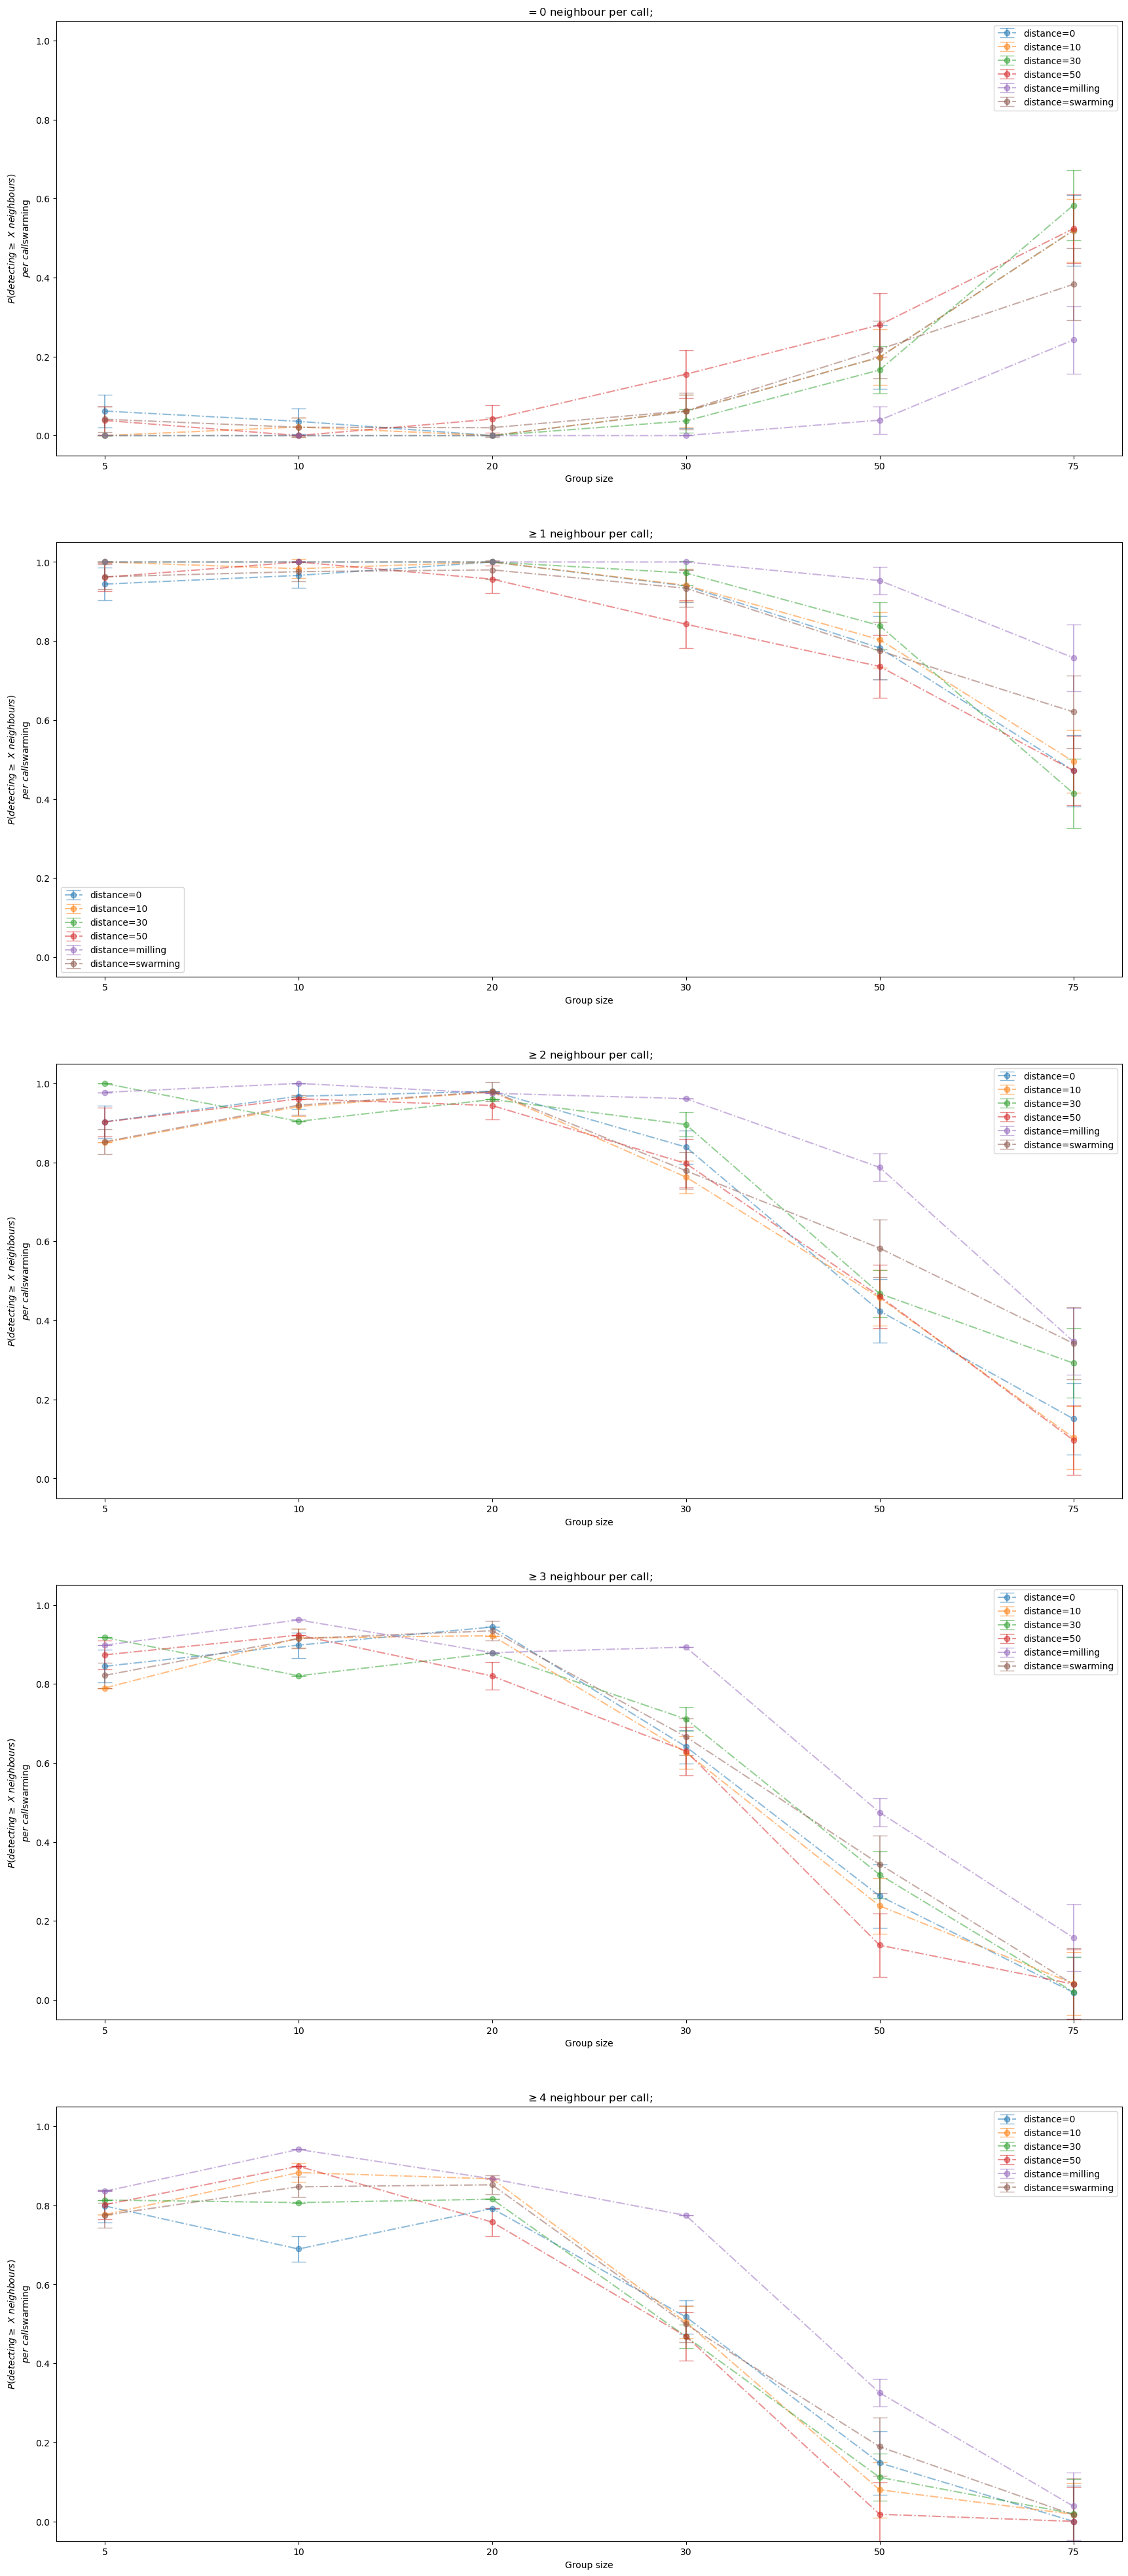

In [122]:
i=0; 
number_of_neighbours_atleast_detected=[0,1,2,3,4]
number_of_columns=1; number_of_rows= int(np.ceil(len(number_of_neighbours_atleast_detected)/number_of_columns))
plt.figure(figsize= (21,50))

for var in list_containing_simulated_data_sorted_by_heading_vars:
        simulation_data= list_containing_simulated_data_sorted_by_heading_vars[var][0][0]
        groupsizes= group_sizes

        key_for_dict= simulation_data["heading_var"][0]
        nbrs_detected_data= store_probability_of_detection_n_neighbour[key_for_dict]

        plt.subplot(number_of_rows,number_of_columns,2)
        plt.errorbar(np.arange(1,len(groupsizes)+1), 
                np.mean(nbrs_detected_data['geq_1neighbour_dist'], axis=1), yerr=np.std(nbrs_detected_data['geq_1neighbour_dist'], axis=1),ls='-.', alpha=0.5, label=f'distance={key_for_dict}', capsize= 8.0, fmt='o')
        
        plt.subplot(number_of_rows,number_of_columns,3)
        plt.errorbar(np.arange(1,len(groupsizes)+1), 
                np.mean(nbrs_detected_data['geq_2neighbour_dist'], axis=1), yerr=np.std(nbrs_detected_data['geq_1neighbour_dist'], axis=1),ls='-.', alpha=0.5, label=f'distance={key_for_dict}', capsize= 8.0, fmt='o')
        
        plt.subplot(number_of_rows,number_of_columns,4)
        plt.errorbar(np.arange(1,len(groupsizes)+1), 
                np.mean(nbrs_detected_data['geq_3neighbour_dist'], axis=1), yerr=np.std(nbrs_detected_data['geq_1neighbour_dist'], axis=1),ls='-.', alpha=0.5, label=f'distance={key_for_dict}', capsize= 8.0, fmt="o")
        
        plt.subplot(number_of_rows,number_of_columns,5)
        plt.errorbar(np.arange(1,len(groupsizes)+1), 
                np.mean(nbrs_detected_data['geq_4neighbour_dist'], axis=1), yerr=np.std(nbrs_detected_data['geq_1neighbour_dist'], axis=1),ls='-.', alpha=0.5, label=f'distance={key_for_dict}', capsize= 8.0, fmt='o')
        
        plt.subplot(number_of_rows,number_of_columns,1)
        plt.errorbar(np.arange(1,len(groupsizes)+1), 
                np.mean(nbrs_detected_data['0neighbours_dist'], axis=1), yerr=np.std(nbrs_detected_data['geq_1neighbour_dist'], axis=1),ls='-.', alpha=0.5, label=f'distance={key_for_dict}', capsize= 8.0, fmt='o')
        i+=1
for i in range(1,6):
        if i==1:
                plt.subplot(number_of_rows,number_of_columns,i)
                plt.yticks(fontsize=10)
                plt.xticks(np.arange(1,len(groupsizes)+1),
                        groupsizes,fontsize=10)
                plt.legend()
                plt.title(f"$={i-1}$ neighbour per call;")
        else: 
                plt.subplot(number_of_rows,number_of_columns,i)
                plt.yticks(fontsize=10)
                plt.xticks(np.arange(1,len(groupsizes)+1),
                        groupsizes,fontsize=10)
                plt.legend()
                plt.title(f"$\geq{i-1}$ neighbour per call;")
        plt.ylabel('$P(detecting \geq \ X \ neighbours)$'+'\n'+ '$per \ call$'+str(simulation_data["heading_var"][0]),
                fontsize=10)
        plt.xlabel('Group size',
                fontsize=10)
        plt.ylim(-0.05,1.05)

{'whiskers': [<matplotlib.lines.Line2D at 0x74f0171c6cb0>,
 'caps': [<matplotlib.lines.Line2D at 0x74f0171c72b0>,
 'boxes': [<matplotlib.lines.Line2D at 0x74f0171c69b0>,
 'medians': [<matplotlib.lines.Line2D at 0x74f0171c78b0>,
 'fliers': [<matplotlib.lines.Line2D at 0x74f01719ef50>,
 'means': []}

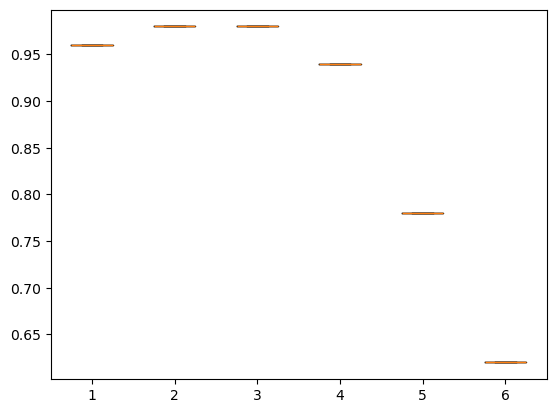

In [93]:
plt.boxplot(nbrs_detected_data['geq_1neighbour_dist'])

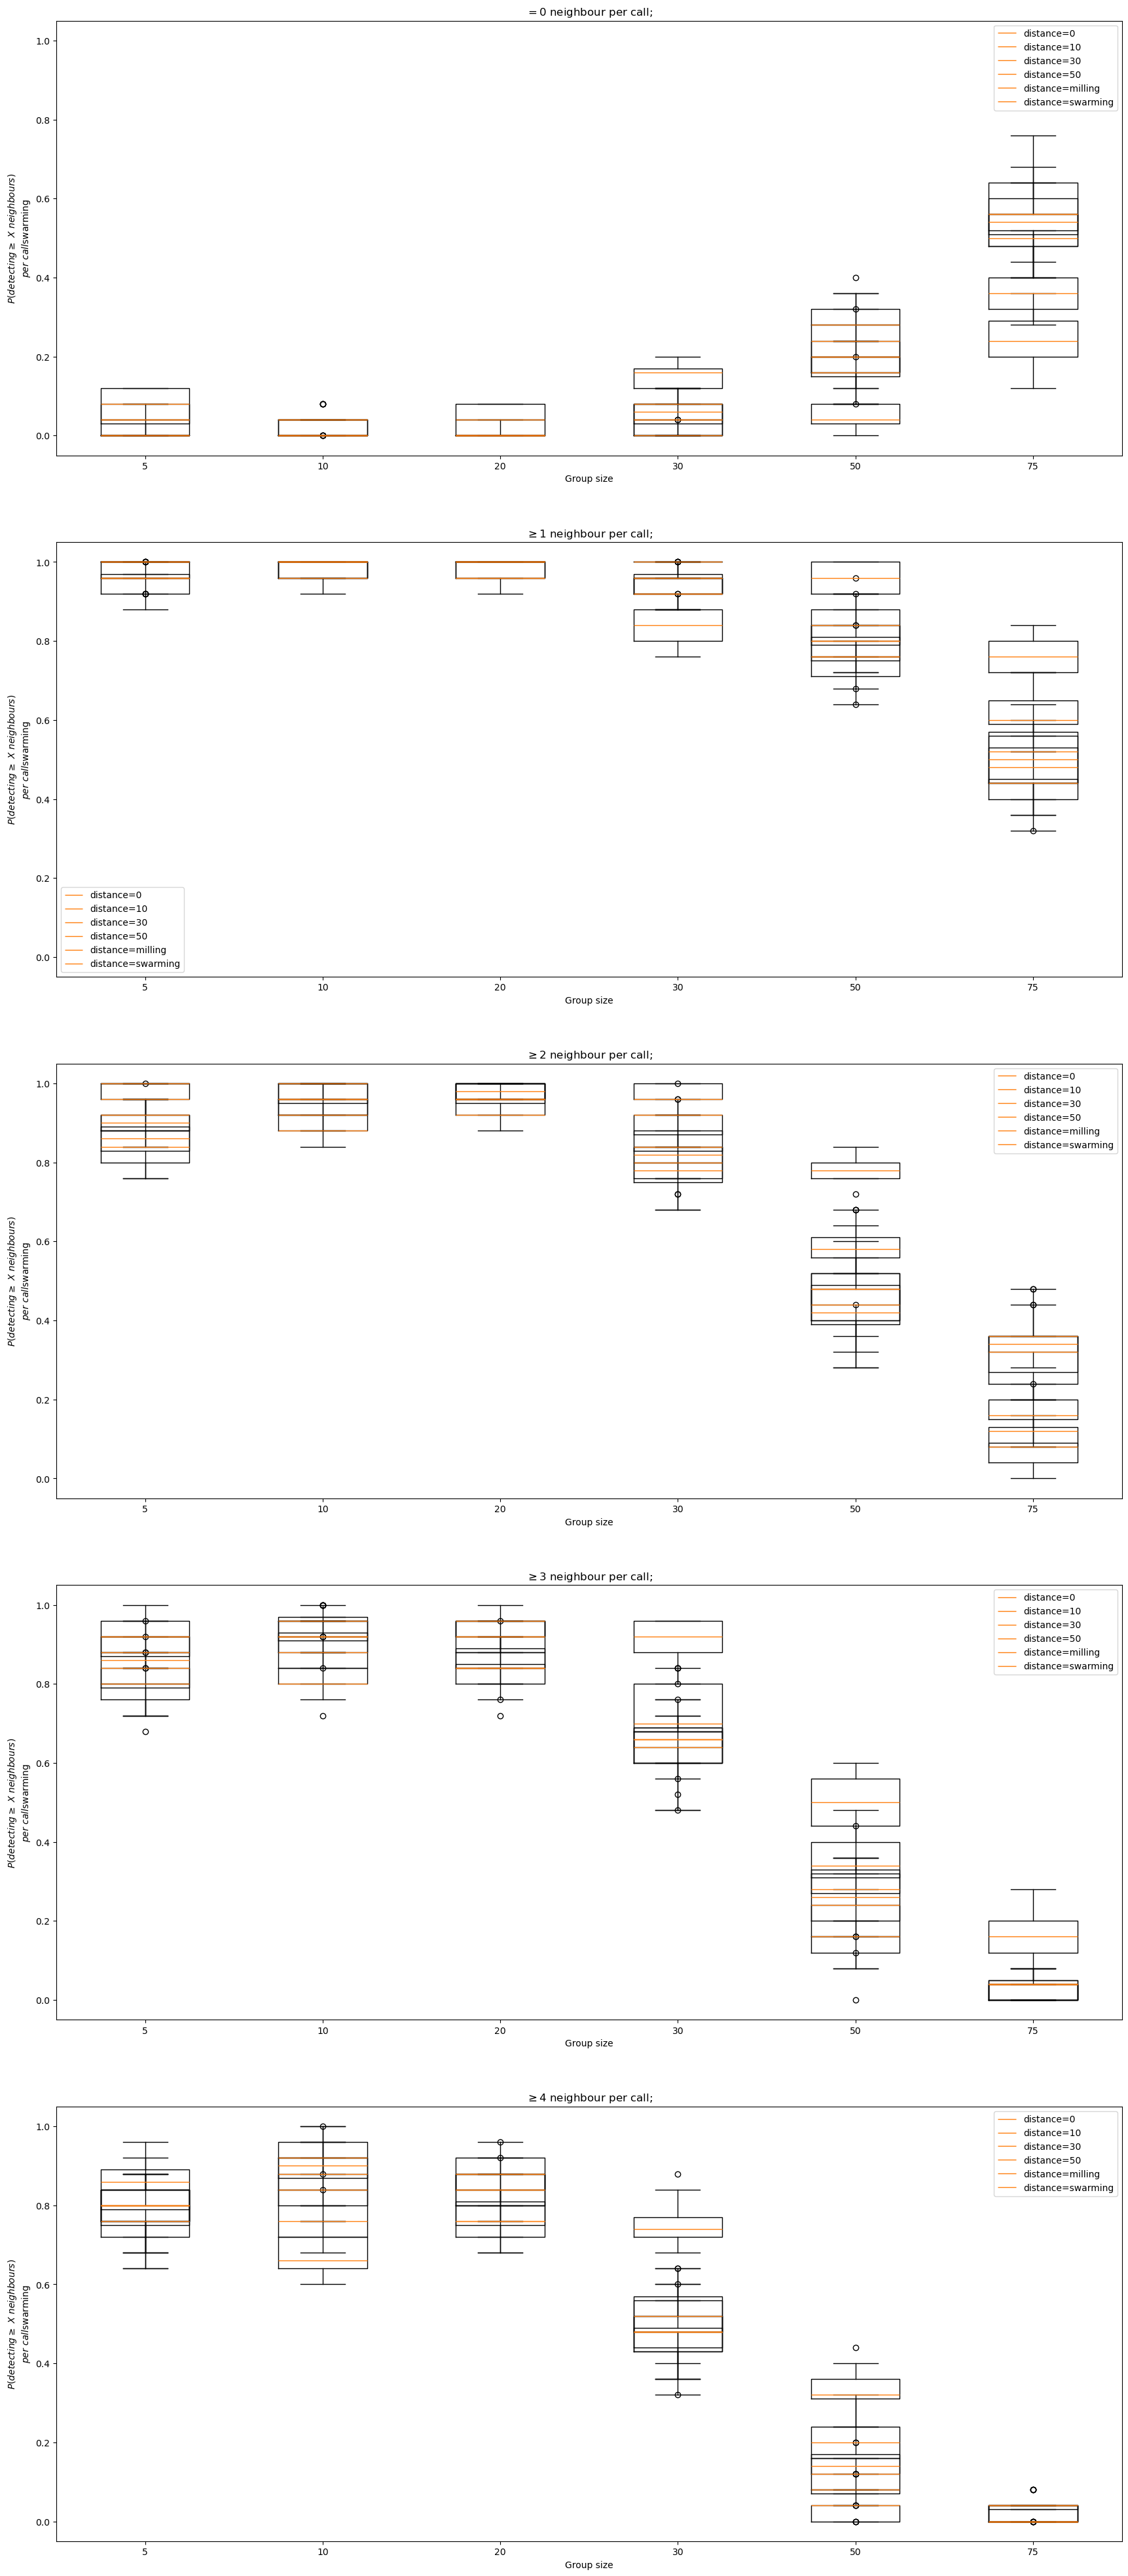

In [96]:
i=0; 
number_of_neighbours_atleast_detected=[0,1,2,3,4]
number_of_columns=1; number_of_rows= int(np.ceil(len(number_of_neighbours_atleast_detected)/number_of_columns))
plt.figure(figsize= (21,50))

for var in list_containing_simulated_data_sorted_by_heading_vars:
        simulation_data= list_containing_simulated_data_sorted_by_heading_vars[var][0][0]
        groupsizes= group_sizes

        key_for_dict= simulation_data["heading_var"][0]
        nbrs_detected_data= store_probability_of_detection_n_neighbour[key_for_dict]

        plt.subplot(number_of_rows,number_of_columns,2)
        plt.boxplot( 
                nbrs_detected_data['geq_1neighbour_dist'], label=f'distance={key_for_dict}')
        
        plt.subplot(number_of_rows,number_of_columns,3)
        plt.boxplot(
                nbrs_detected_data['geq_2neighbour_dist'], label=f'distance={key_for_dict}')
        
        plt.subplot(number_of_rows,number_of_columns,4)
        plt.boxplot(
                nbrs_detected_data['geq_3neighbour_dist'], label=f'distance={key_for_dict}')
        
        plt.subplot(number_of_rows,number_of_columns,5)
        plt.boxplot(
                nbrs_detected_data['geq_4neighbour_dist'], label=f'distance={key_for_dict}')
        
        plt.subplot(number_of_rows,number_of_columns,1)
        plt.boxplot(
                nbrs_detected_data['0neighbours_dist'], label=f'distance={key_for_dict}')
        i+=1
for i in range(1,6):
        if i==1:
                plt.subplot(number_of_rows,number_of_columns,i)
                plt.yticks(fontsize=10)
                plt.xticks(np.arange(1,len(groupsizes)+1),
                        groupsizes,fontsize=10)
                plt.legend()
                plt.title(f"$={i-1}$ neighbour per call;")
        else: 
                plt.subplot(number_of_rows,number_of_columns,i)
                plt.yticks(fontsize=10)
                plt.xticks(np.arange(1,len(groupsizes)+1),
                        groupsizes,fontsize=10)
                plt.legend()
                plt.title(f"$\geq{i-1}$ neighbour per call;")
        plt.ylabel('$P(detecting \geq \ X \ neighbours)$'+'\n'+ '$per \ call$'+str(simulation_data["heading_var"][0]),
                fontsize=10)
        plt.xlabel('Group size',
                fontsize=10)
        plt.ylim(-0.05,1.05)

0
10
30
50
milling
swarming


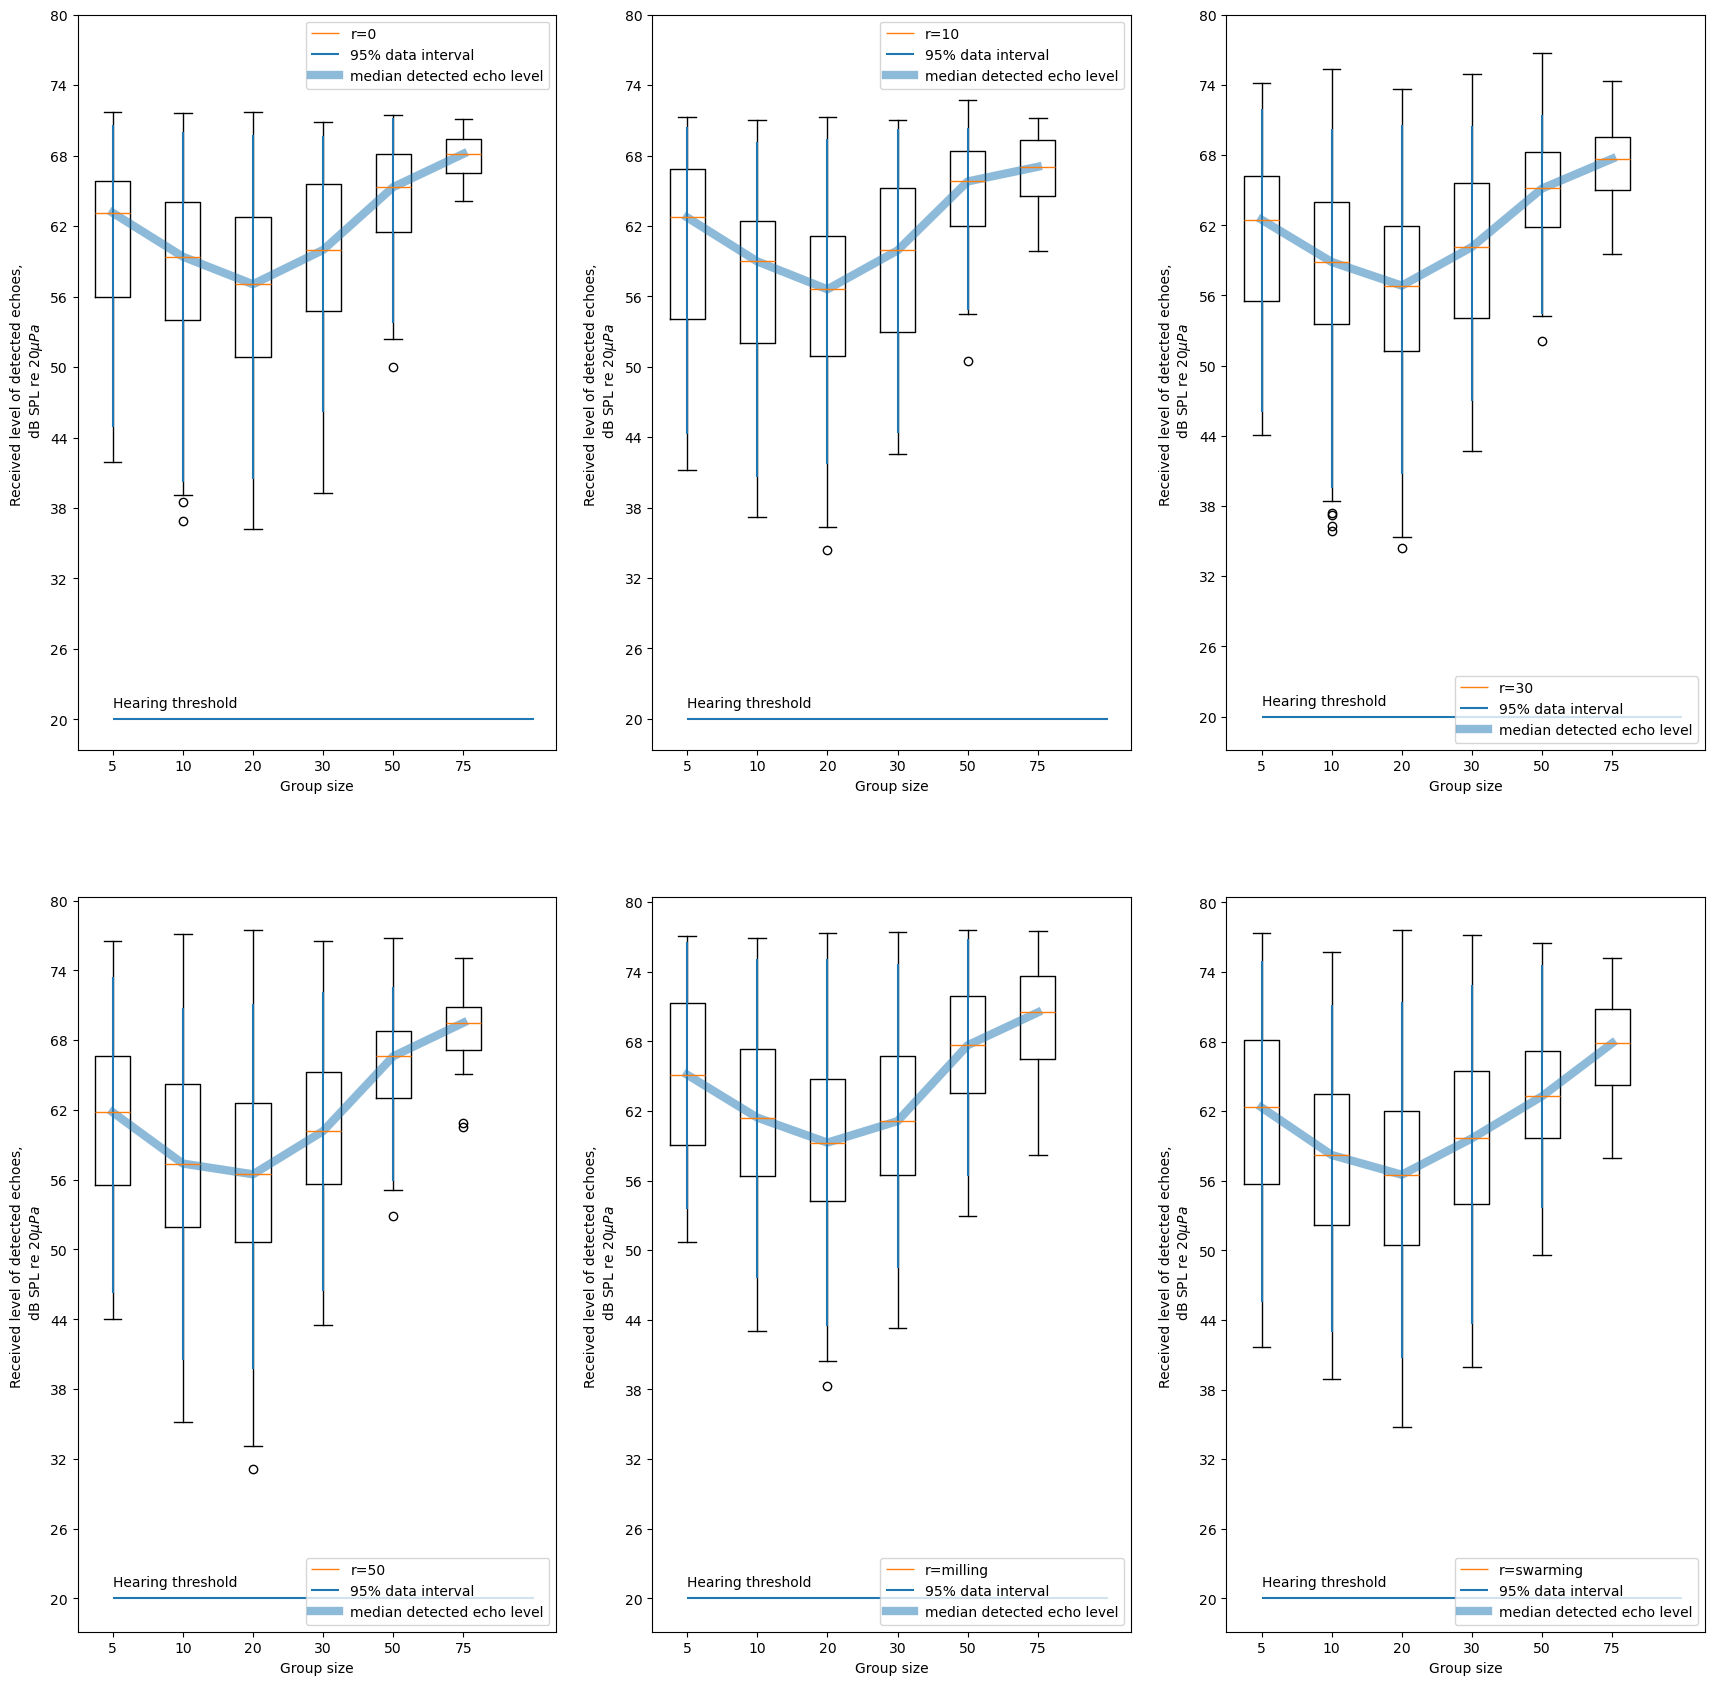

In [65]:
i=0; 
number_of_columns=3; number_of_rows= int(np.ceil(len(group_sizes)/number_of_columns))
plt.figure(figsize= (21,21))
for var in list_containing_simulated_data_sorted_by_heading_vars:
        simulation_data= list_containing_simulated_data_sorted_by_heading_vars[var][0][0]
        groupsizes= group_sizes

        key_for_dict= simulation_data["heading_var"][0]
        nbrs_detected_data= store_probability_of_detection_n_neighbour[key_for_dict]

        plt.subplot(number_of_rows,number_of_columns,i+1)
        plt.boxplot(nbrs_detected_data['echolevels'][:], label=f"r={key_for_dict}");
        plt.vlines(range(1,len(nbrs_detected_data['95%ile_echolevels'])+1),nbrs_detected_data['5%ile_echolevels'],
                                                                        nbrs_detected_data['95%ile_echolevels'],
                                label='95% data interval')

        plt.plot(range(1,len(groupsizes)+1), nbrs_detected_data['median_echolevels'], linewidth=6, alpha=0.5,
                label='median detected echo level')
        plt.ylabel('Received level of detected echoes, \n dB SPL re 20$\mu Pa$',
                                                fontsize=10)
        plt.xticks(np.arange(1,len(groupsizes)+1), groupsizes, fontsize=10)
        plt.hlines([20],1,len(groupsizes)+1)
        plt.yticks(np.arange(20,86,6),np.arange(20,86,6), fontsize=10)
        plt.text(1,21,'Hearing threshold', fontsize=10)
        plt.xlabel('Group size', fontsize=10)
        plt.legend()
        print(key_for_dict)
        i+=1

0
10
30
50
milling
swarming


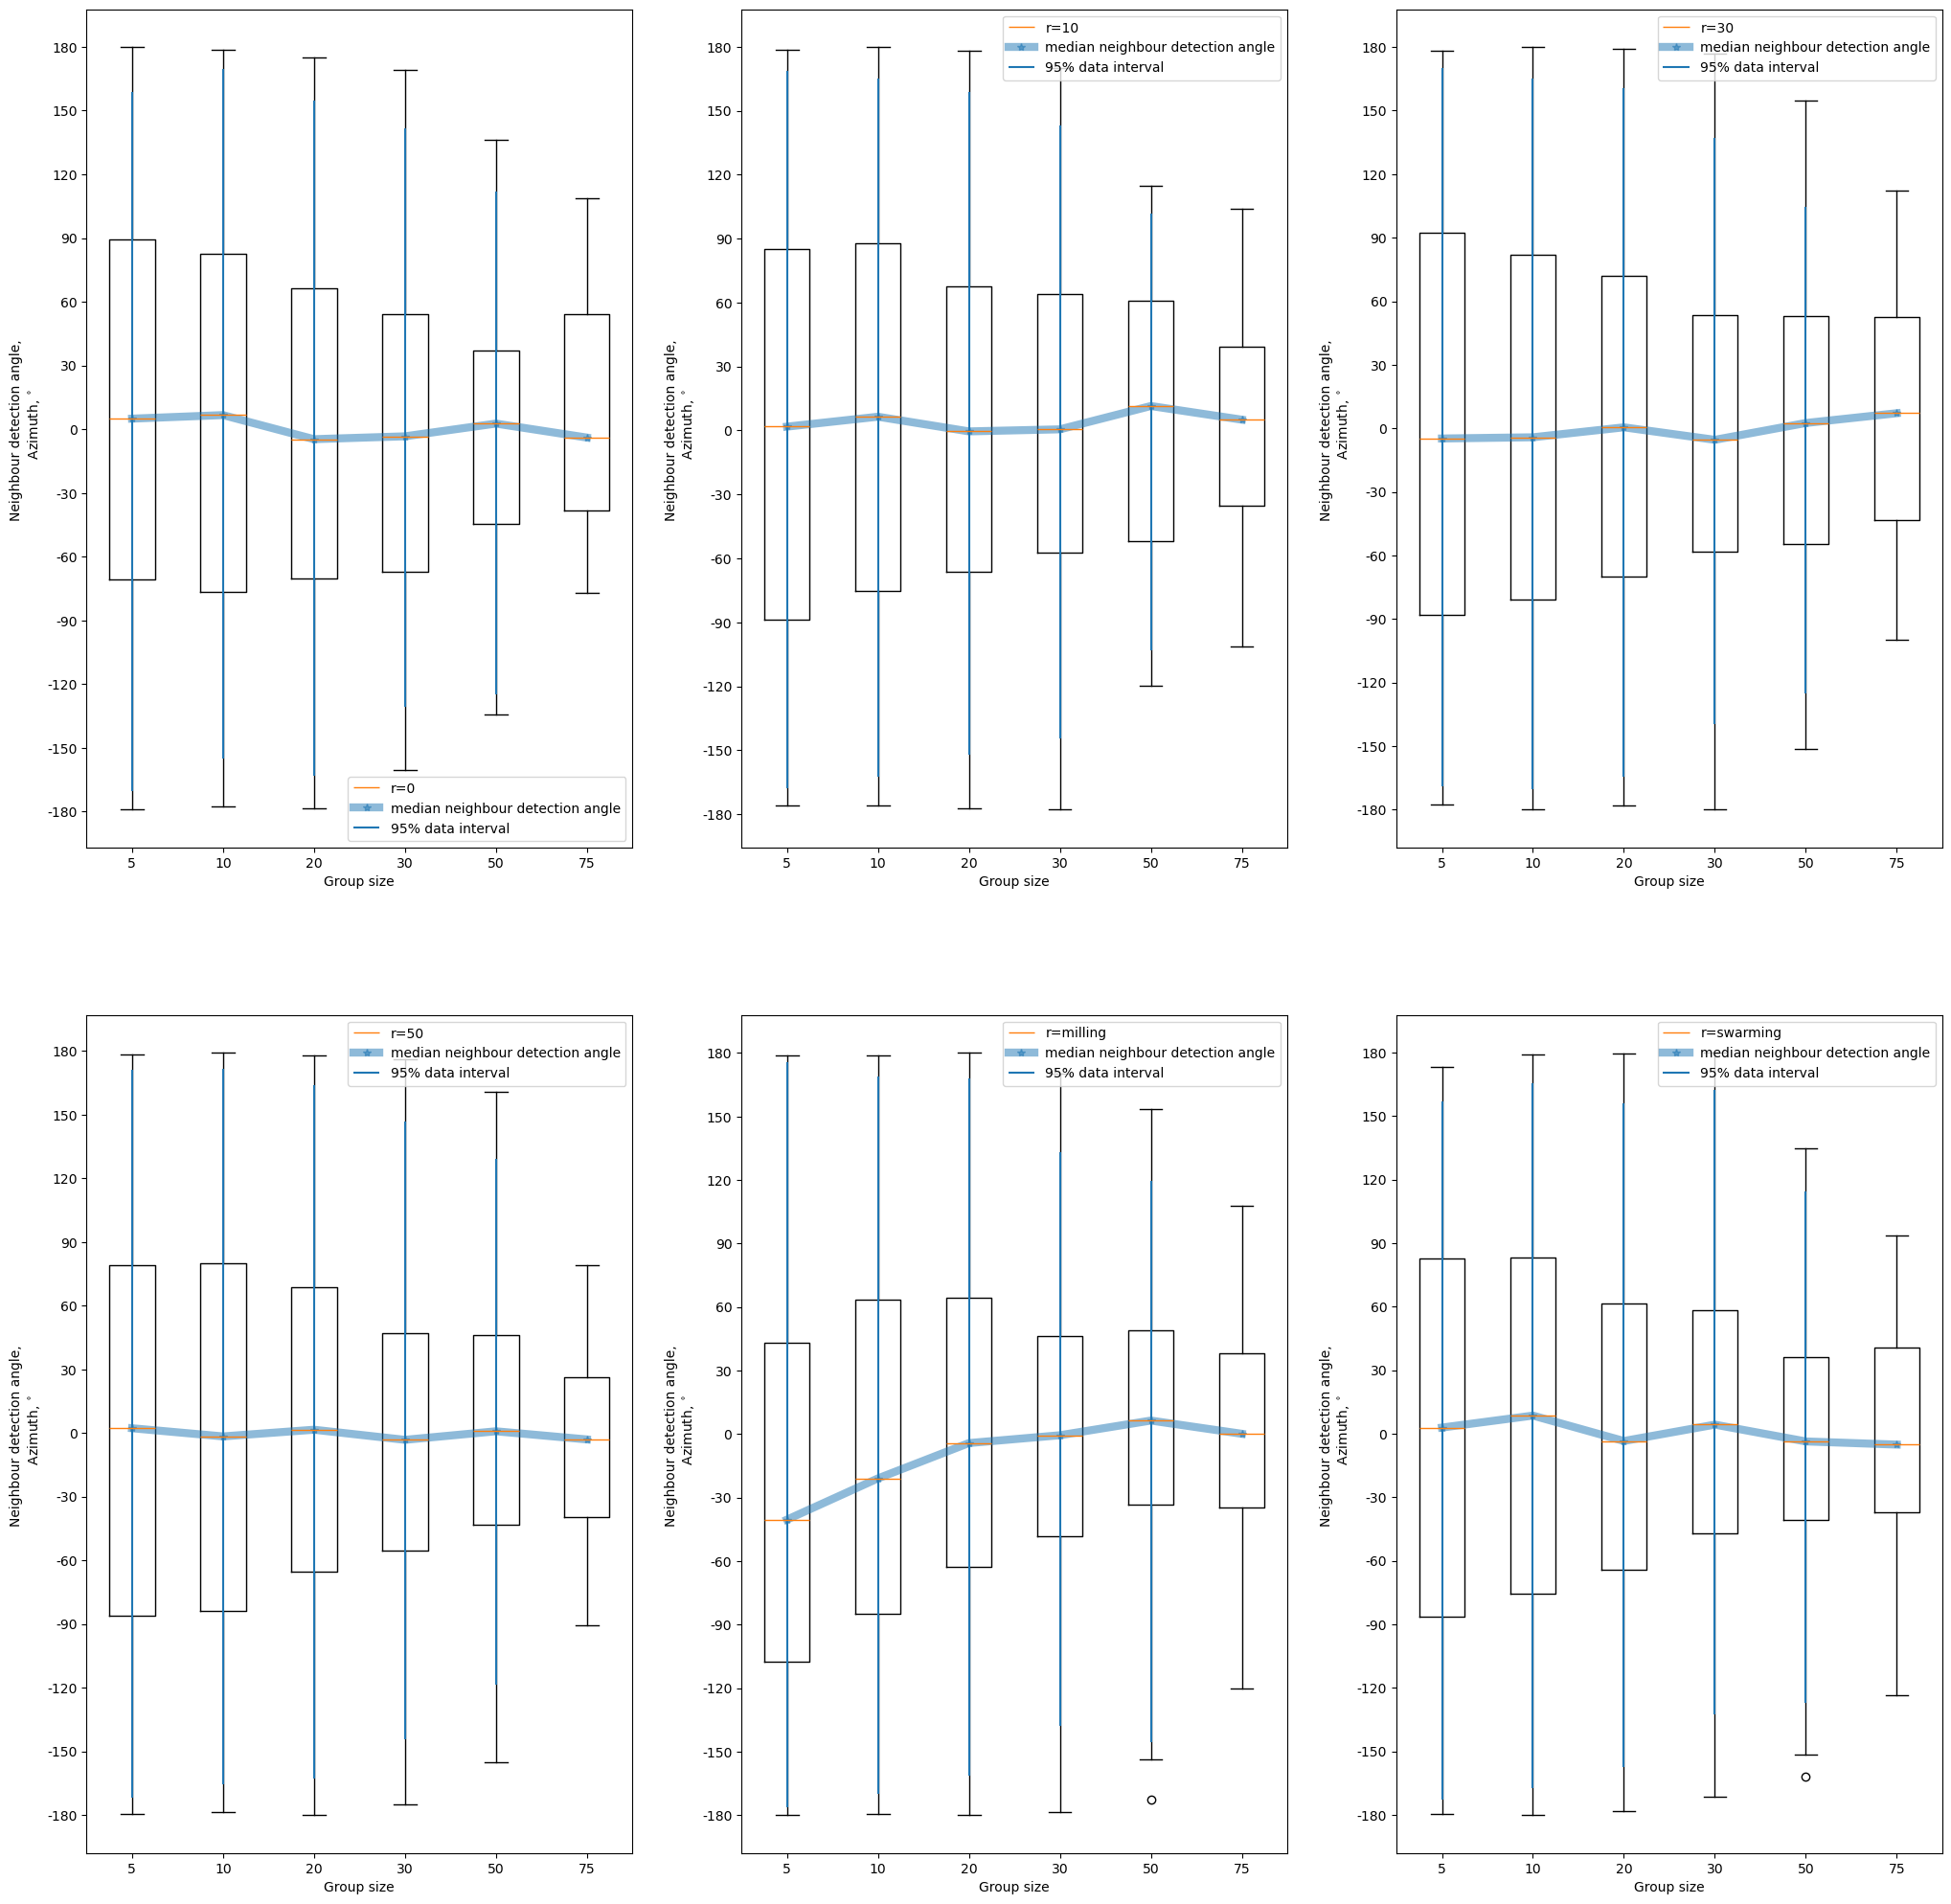

In [66]:
i=0; 
number_of_columns=3; number_of_rows= int(np.ceil(len(group_sizes)/number_of_columns))
plt.figure(figsize= (25,25))
for var in list_containing_simulated_data_sorted_by_heading_vars:
        simulation_data= list_containing_simulated_data_sorted_by_heading_vars[var][0][0]
        groupsizes= group_sizes

        key_for_dict= simulation_data["heading_var"][0]
        nbrs_detected_data= store_probability_of_detection_n_neighbour[key_for_dict]

        plt.subplot(number_of_rows,number_of_columns,i+1)
        plt.boxplot(nbrs_detected_data['neighbours_azimuth'][:], label=f"r={key_for_dict}")
        plt.plot(np.arange(1,7), nbrs_detected_data['median_neighbours_azimuth'], '-*', linewidth=6,
                        alpha=0.5, label='median neighbour detection angle')
        plt.vlines(range(1,len(nbrs_detected_data['5%ile_neighbours_azimuth'])+1),nbrs_detected_data['5%ile_neighbours_azimuth'],
                nbrs_detected_data['95%ile_neighbours_azimuth'], label='95% data interval')
        #plt.plot(np.arange(1,8), nbrs_detected_data['95%ile_neighbours_azimuth'], 'g')
        #plt.plot(np.arange(1,8), nbrs_detected_data['5%ile_neighbours_azimuth'], 'g', label='95%  neighbour detection range')

        plt.yticks(np.arange(-180,210,30), np.arange(-180,210,30), fontsize=10)
        plt.xticks(np.arange(1,7), groupsizes, fontsize=10)
        plt.legend()
        plt.ylabel('Neighbour detection angle, \n  Azimuth, $^{\circ}$', fontsize=10)
        plt.xlabel('Group size', fontsize=10)


        print(key_for_dict)
        i+=1

In [67]:
def modify_dict_for_seaborn(input_dict,key_x,key_y):
    radial_dist= input_dict.keys()
    x,y,hue= [], [], []
    for r in radial_dist:
        data_to_plotted= input_dict[r]
        y_axis_raw= data_to_plotted[key_y]
        x_axis_raw= data_to_plotted[key_x]
        # print(x_axis_raw)
        for index_group_sizes in range(len(x_axis_raw)):
            group_size= x_axis_raw[index_group_sizes]
            y_corresponding_to_group_size= y_axis_raw[index_group_sizes]
            # print(y_corresponding_to_group_size)
            for entry in y_corresponding_to_group_size:
                # print(entry)
                y.append(entry)
                x.append(group_size)
                hue.append(r)

    return x,y,hue

In [68]:
len(store_probability_of_detection_n_neighbour["10"]["neighbours_azimuth"])

6

Text(0.5, 1.0, 'neighbour azimuth across groupsize for heading var= swarming')

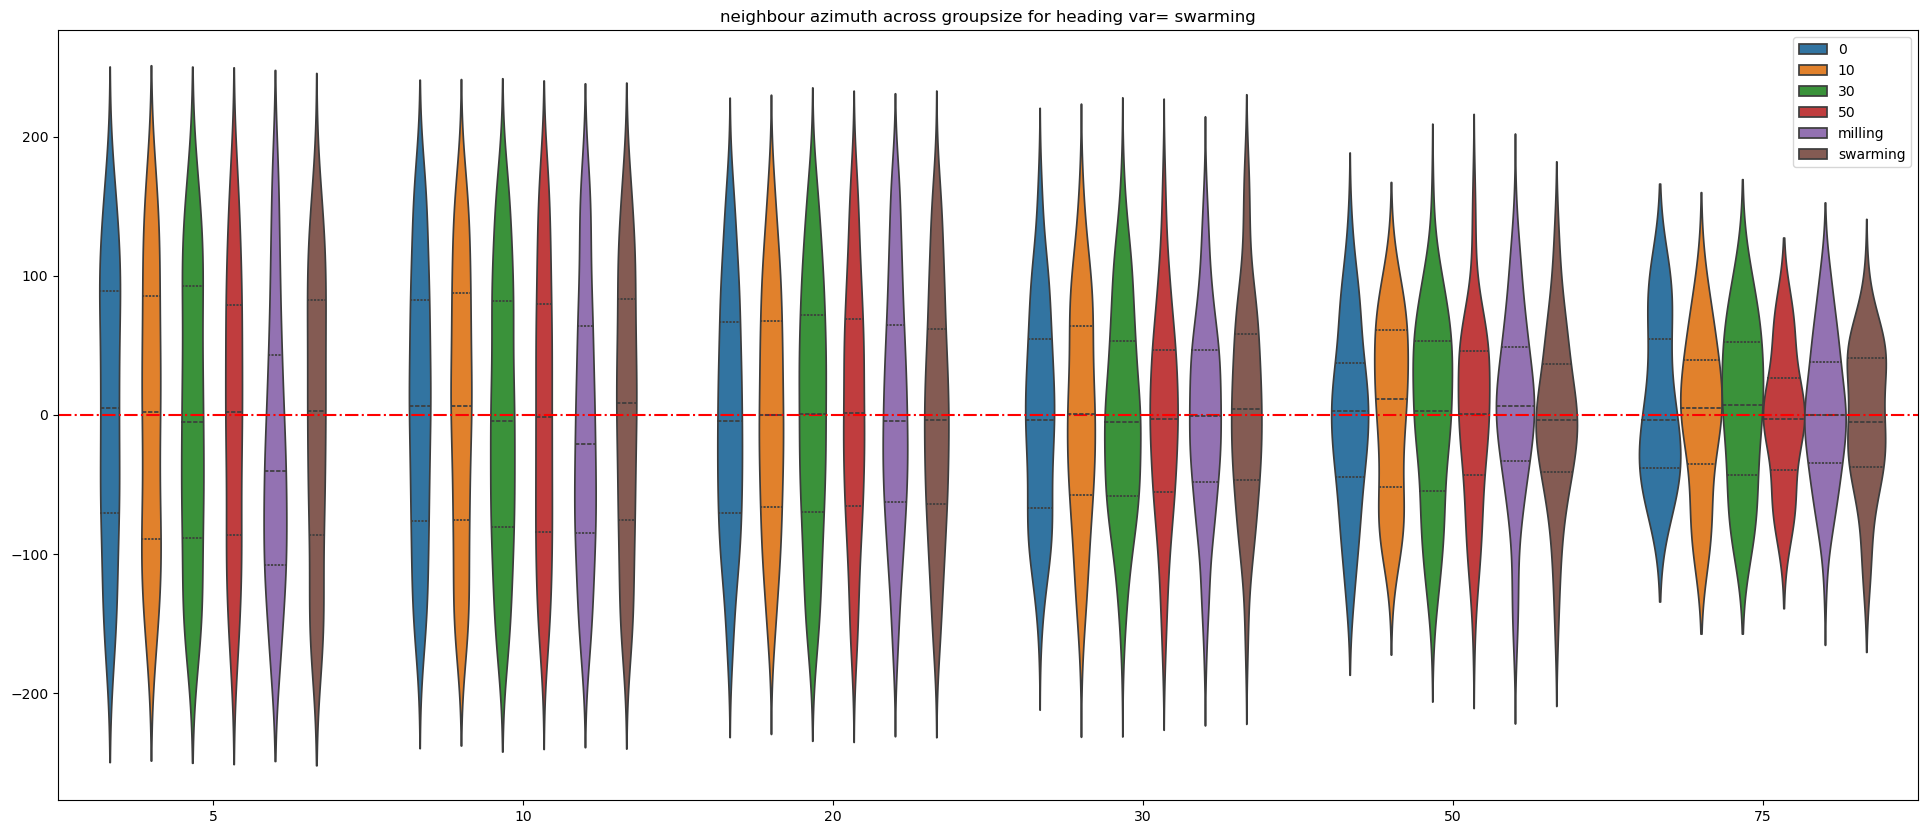

In [69]:
import seaborn as sns
x,y,hue= modify_dict_for_seaborn(store_probability_of_detection_n_neighbour, "group_sizes", "neighbours_azimuth")
plt.figure(figsize=(24,10))
plt.axhline(0, ls= "-.", color="red")
sns.violinplot(x=x, y=y, hue=hue, inner="quart", hue_order=store_probability_of_detection_n_neighbour.keys())
plt.title("neighbour azimuth across groupsize for heading var= "+ str(heading_var))

Text(0.5, 1.0, 'neighbour azimuth across groupsize for heading var= swarming')

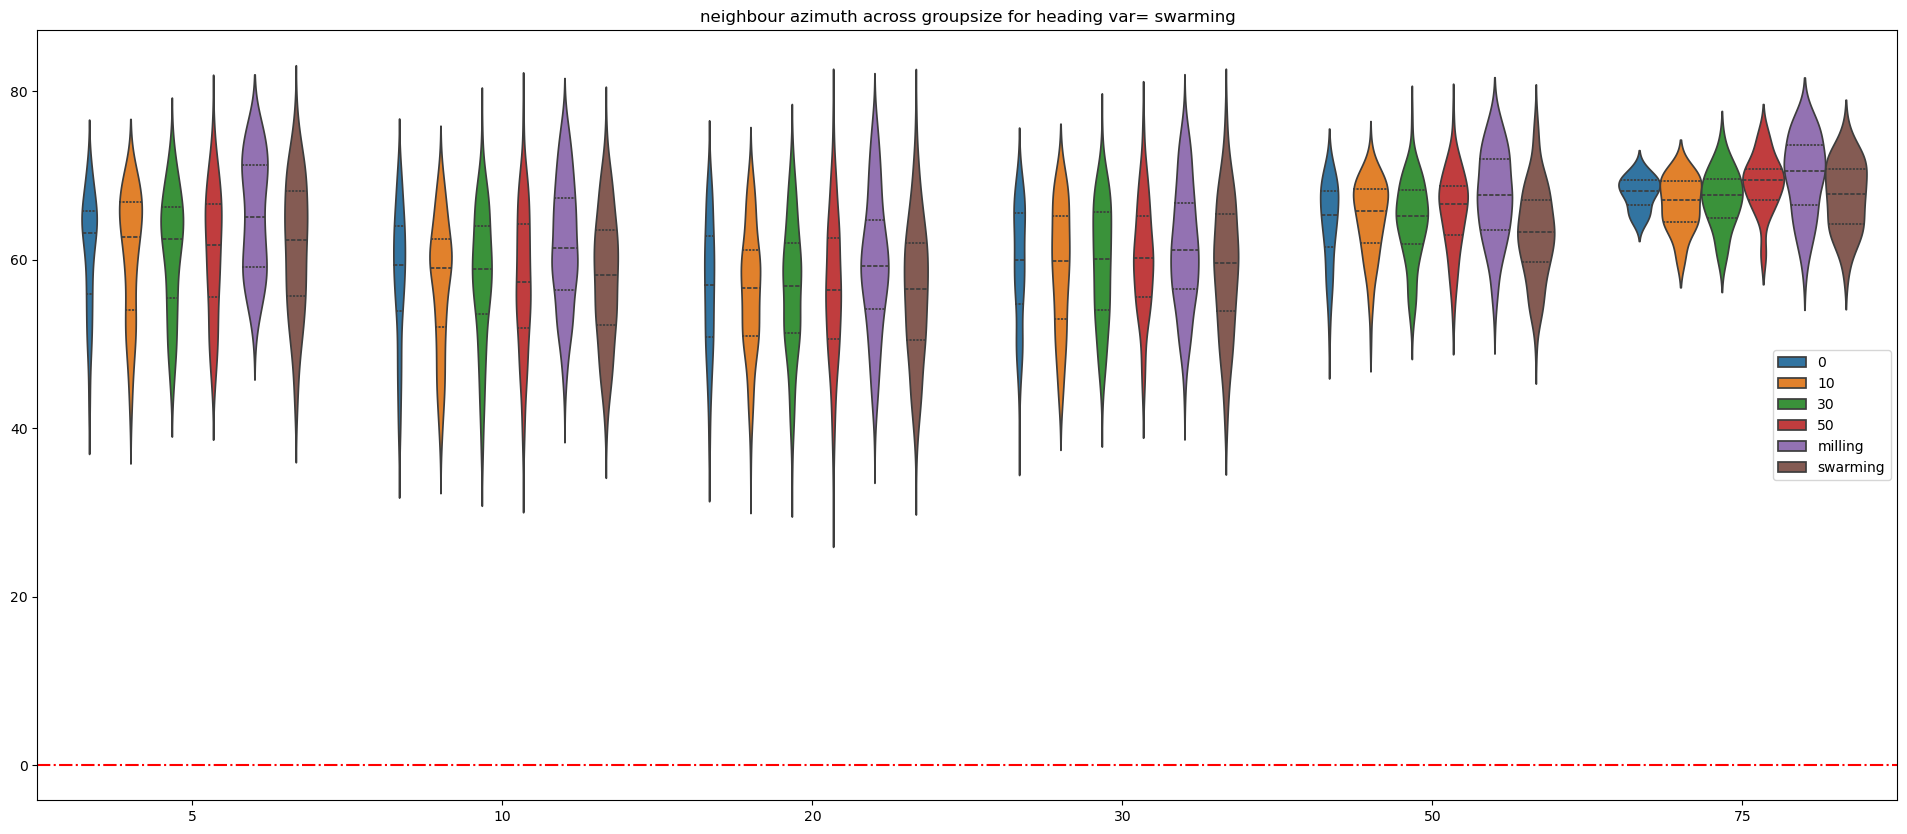

In [70]:
import seaborn as sns
x,y,hue= modify_dict_for_seaborn(store_probability_of_detection_n_neighbour, "group_sizes", "echolevels")
plt.figure(figsize=(24,10))
plt.axhline(0, ls= "-.", color="red")
sns.violinplot(x=x, y=y, hue=hue, inner="quart", hue_order=store_probability_of_detection_n_neighbour.keys())
plt.title("neighbour azimuth across groupsize for heading var= "+ str(heading_var))

In [71]:
hue

[np.str_('0'),
 np.str_('0'),
 np.str_('0'),
 np.str_('0'),
 np.str_('0'),
 np.str_('0'),
 np.str_('0'),
 np.str_('0'),
 np.str_('0'),
 np.str_('0'),
 np.str_('0'),
 np.str_('0'),
 np.str_('0'),
 np.str_('0'),
 np.str_('0'),
 np.str_('0'),
 np.str_('0'),
 np.str_('0'),
 np.str_('0'),
 np.str_('0'),
 np.str_('0'),
 np.str_('0'),
 np.str_('0'),
 np.str_('0'),
 np.str_('0'),
 np.str_('0'),
 np.str_('0'),
 np.str_('0'),
 np.str_('0'),
 np.str_('0'),
 np.str_('0'),
 np.str_('0'),
 np.str_('0'),
 np.str_('0'),
 np.str_('0'),
 np.str_('0'),
 np.str_('0'),
 np.str_('0'),
 np.str_('0'),
 np.str_('0'),
 np.str_('0'),
 np.str_('0'),
 np.str_('0'),
 np.str_('0'),
 np.str_('0'),
 np.str_('0'),
 np.str_('0'),
 np.str_('0'),
 np.str_('0'),
 np.str_('0'),
 np.str_('0'),
 np.str_('0'),
 np.str_('0'),
 np.str_('0'),
 np.str_('0'),
 np.str_('0'),
 np.str_('0'),
 np.str_('0'),
 np.str_('0'),
 np.str_('0'),
 np.str_('0'),
 np.str_('0'),
 np.str_('0'),
 np.str_('0'),
 np.str_('0'),
 np.str_('0'),
 np.str_('